In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict
from Bio.Seq import Seq
import subprocess
import os
from tqdm import tqdm
from loguru import logger
import csv

In [14]:
logger.add('analysis.log')

2

In [15]:
def rev_comp(seq):
    comp_dict = str.maketrans('ACGTacgt', 'TGCAtgca')
    return seq.translate(comp_dict)[::-1]

In [121]:
def align(ref_reads):
    '''Create the aligned sequences for all reads, by adding '-' to the left and right of the read sequence, according to the position of the read on the reference.
    Handles both forward and reverse reads

    Parameters:
    ref_reads (pd.DataFrame): the dataframe containing the reads aligned to the reference, with the following columns: 'qseqid', 'qstart', 'qend', 'qframe', 'qstrand', 'sstart', 'send', 'qseq', 'qseq_translated', 'length', 'evalue', 'bitscore', 'gapopen', 'cigar', 'full_qseq'

    Returns:
    all_prot (list): list of all aligned sequences, with '-' added to the left and right of the read sequence, according to the position of the read on the reference
    all_ids (list): list of all read ids
    all_info (list): list of all read info, including the strand and the aligned sequence
    '''
    all_prot = []
    all_ids = []
    all_info = []
    max_pos = ref_reads['sstart'].max()*3 + 150
    for cpos,crow in ref_reads.iterrows():
        cseq = crow['full_qseq']
        cframe = crow['qframe']
        if crow['qstrand']=='-':
            cseq = rev_comp(cseq[crow['qend']:crow['qstart']])
            cfull_seq = cseq
            cfull_seq = '-'*((crow['sstart'])*3) + cfull_seq
            # complete to the right with '-' up to the max position
            cfull_seq = cfull_seq + '-'*(max_pos - len(cfull_seq))
            # continue
        else:
            start_pos = crow['qstart']-1
            end_pos = crow['qend']-1
            cfull_seq = cseq[start_pos:end_pos]
            cfull_seq = '-'*(crow['sstart']*3) + cfull_seq
            cfull_seq = cfull_seq + '-'*(max_pos - len(cfull_seq))
        all_prot.append(cfull_seq)
        all_ids.append(crow['qseqid'])
        all_info.append([crow['qstrand'], cfull_seq])
    return all_prot, all_ids, all_info

In [122]:
def calc_windows(all_prot, window_size=25):
    pos_nums = defaultdict(lambda: defaultdict(int))
    for cseq in all_prot:
        for i in range(500):
            tseq = cseq[i:i+window_size]
            if '-' in tseq:
                continue
            pos_nums[i][tseq] += 1
    return pos_nums

In [123]:
def parse_results(res_dir, uniref_id, plot_it=False,window_size=25):
    import glob
    import pandas as pd
    import os

    result_files = glob.glob(os.path.join(res_dir, f"*-splits/{uniref_id}"))
    all_num = {}
    all_tot_reads = {}
    columns = 'sseqid qseqid qstart qend qframe qstrand sstart send qseq qseq_translated length evalue bitscore gapopen cigar full_qseq'.split(' ')
    for res_file in result_files:
        print(f'parsing file {res_file}')
        res_df = pd.read_csv(res_file, sep='\t', header=None)
        res_df.columns = columns
        print(f'found {len(res_df)} matching reads in file {res_file}')
        all_prot, all_ids, all_info = align(res_df)
        pos_nums = calc_windows(all_prot, window_size=window_size)
        # num_diff = [len(pos_nums[i]) for i in range(500)]
        num_diff = [np.sum(np.array(list(pos_nums[i].values()))>1) for i in range(500)]
        num_unique = np.percentile(num_diff, 95)
        if plot_it:
            plt.figure(figsize=(25,6))
            plt.bar(range(500), num_diff)
            plt.title(f'Uniref ID: {uniref_id} from file {os.path.basename(res_file)} total reads: {len(res_df)}')
        print(f'sample {os.path.basename(res_file)}: 95% unique: {num_unique}, total reads: {len(res_df)}')
        all_num[res_file.split('/')[-2]] = num_unique
        all_tot_reads[res_file.split('/')[-2]] = len(res_df)
    return all_num, all_tot_reads

In [124]:
res_file = '/pita/users/amnon/shotgun/human-cd/SRR33650745-splits/UniRef50_A5ZTV7.txt'
res_df = pd.read_csv(res_file, sep='\t', header=None)
columns = 'sseqid qseqid qstart qend qframe qstrand sstart send qseq qseq_translated length evalue bitscore gapopen cigar full_qseq'.split(' ')
res_df.columns = columns
print(f'found {len(res_df)} matching reads in file {res_file}')
all_prot, all_ids, all_info = align(res_df)
pos_nums = calc_windows(all_prot, window_size=150)

found 1512 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650745-splits/UniRef50_A5ZTV7.txt


In [125]:
all_prot

['---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------CTCTTTCACTCCCCTCCCGGGGTCCTTTTCACCTTTCCTTCACAGTACTATGCGCTATCGGTCACTAAGTAGTATTTAGCCTTAGGGGGTGGTCCCCCTTACTTCCCACAAGGTTCCTC----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------',
 '------------------AAATTCAGTGCTCTACCTCCATAAGACTAAATCGAGGCTAGCCCTAAAGCTATTTCGAGGAGAACCAGCTATCTCCGGGTTCGATTGGAATTTCTCCCCTATCCACACCTCATGCCCAC----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [111]:
res_df['qseq'].value_counts()[:20]

qseq
CTTGTAGGCACAGGGTTTCAGGTTCTTTTTCACTCCCCTCCCGGGGTGCTTTTCACCTTTCCTTCACAGTACTATACGCTATCGGTCACTGGGTAGTATTTAGGGTTG                21
GCCCTGTTAAGACTTGGTATCCCTTCGGCTCCGCACCTTAAGTGCTTAACCTTGCCAGTATCCGCAACTCGCCGGACCGTTCTACAAAAAGTACGCGGT                         17
GTGTGGATAGGGGAGAAATTCCAATCGAACCCGGAGATAGCTGGTTCTCCTCGAAATAGCTTTAGGGCTAGCCTCGATTTAGTCTTATGGAGGTAGAGCACTGAATTTCCGCGGGGGCGT    16
GCCCTGTTAAGACTTGGTATCCCTTCGGCTCCGCACCTTAAGTGCTTAACCTTGCCAGTATCCGCAACTCGCCGG                                                 15
GTACTGTGAAGGAAAGGTGAAAAGGACCCCGGGAGGGGAGTGAAAGAGAACCTGAAACCCTGTGTTTACAAGCTGTGGAAGTTCTTTAAATGAACAACCGCGTACTTTTTGTAGAACGGT    13
GCCCTGTTAAGACTTGGTATCCCTTCGGCTCCGCACCTTAAGTGCTTAACCTTGCCAGTATCCGCAACTCGCCGGACC                                              12
TTGTAGAACGGTCCGGCGAGTTGCGGATACTGGCAAGGTTAAGCACTTAAGGTGCGGAGCCGAAGGGATACCAAGTCTTAACAGGGC                                     12
GAATACGGGGGGACCACCCTCCAACCCTAAATACTACCCAGTGACCGATAGCGTATAGTACTGTGAAGGAAAGGTGAAAAGCACCCCGGGAGGGGAGTGAAAAAGA

In [93]:
# sort each value in pos_nums by values
for i in pos_nums.keys():
    pos_nums[i] = dict(sorted(pos_nums[i].items(), key=lambda item: item[1], reverse=True))

In [ ]:
# denoise the reads


In [94]:
pos_nums

defaultdict(<function __main__.calc_windows.<locals>.<lambda>()>,
            {445: {'': 1400},
             446: {'': 1400},
             447: {'': 1400},
             448: {'': 1431},
             449: {'': 1431},
             450: {'': 1431},
             451: {'': 1437},
             452: {'': 1437},
             453: {'': 1437},
             454: {'': 1462},
             455: {'': 1462},
             456: {'': 1462},
             457: {'': 1476},
             458: {'': 1476},
             459: {'': 1476},
             460: {'': 1488},
             461: {'': 1488},
             462: {'': 1488},
             463: {'': 1500},
             464: {'': 1500},
             465: {'': 1500},
             466: {'': 1533},
             467: {'': 1533},
             468: {'': 1533},
             469: {'': 1542},
             470: {'': 1542},
             471: {'': 1542},
             472: {'': 1566},
             473: {'': 1566},
             474: {'': 1566},
             475: {'': 1598},
    

parsing file /pita/users/amnon/shotgun/human-cd/SRR33650713-splits/UniRef50_A5ZTV7.txt
found 2307 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650713-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 42.0, total reads: 2307
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650745-splits/UniRef50_A5ZTV7.txt
found 1512 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650745-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 17.049999999999955, total reads: 1512
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650701-splits/UniRef50_A5ZTV7.txt
found 1516 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650701-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 28.0, total reads: 1516
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650791-splits/UniRef50_A5ZTV7.txt
found 3147 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650791-splits/UniRef50_A5ZTV7.txt
sample UniRef5

/tmp/ipykernel_4642/3353882931.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(25,6))


sample UniRef50_A5ZTV7.txt: 95% unique: 21.049999999999955, total reads: 948
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650720-splits/UniRef50_A5ZTV7.txt
found 751 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650720-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 17.0, total reads: 751
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650694-splits/UniRef50_A5ZTV7.txt
found 1056 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650694-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 21.0, total reads: 1056
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650726-splits/UniRef50_A5ZTV7.txt
found 1467 matching reads in file /pita/users/amnon/shotgun/human-cd/SRR33650726-splits/UniRef50_A5ZTV7.txt
sample UniRef50_A5ZTV7.txt: 95% unique: 31.0, total reads: 1467
parsing file /pita/users/amnon/shotgun/human-cd/SRR33650714-splits/UniRef50_A5ZTV7.txt
found 686 matching reads in file /pita/users/amnon/shotgun/hu

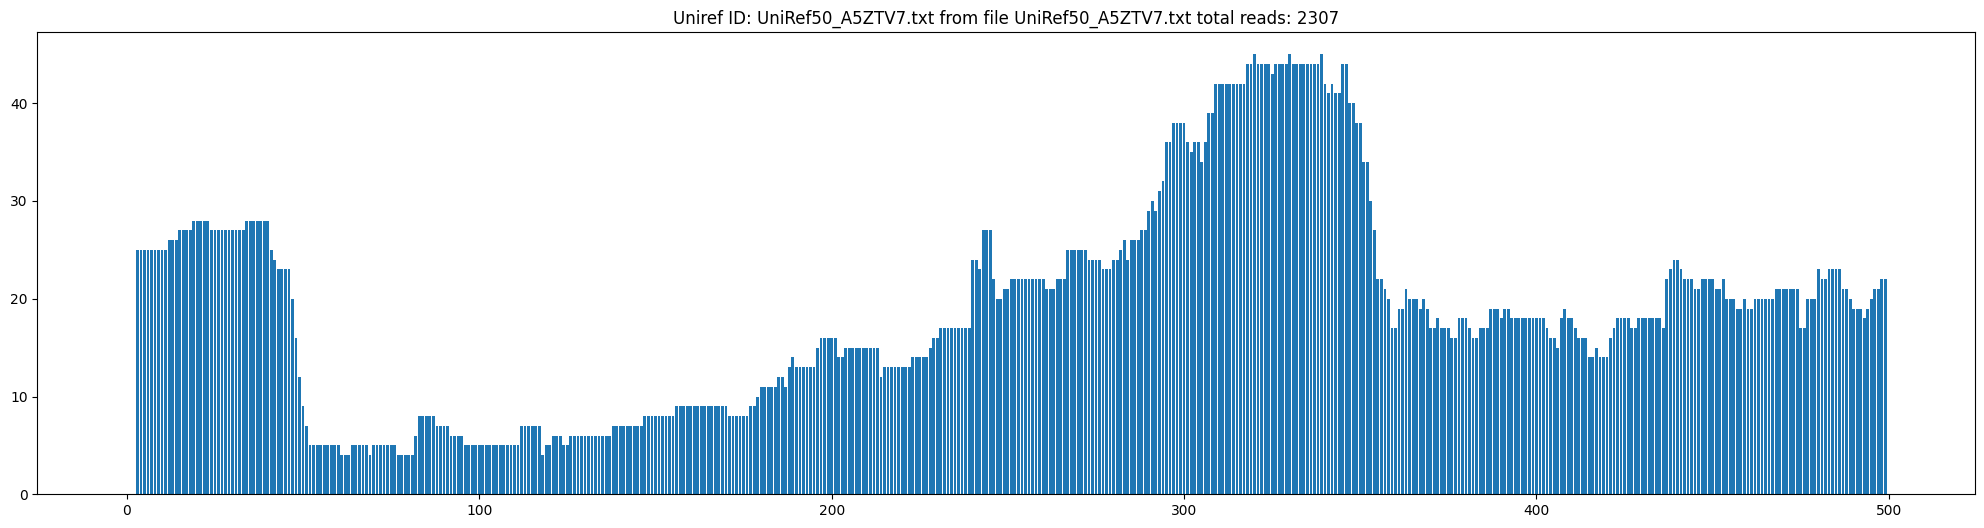

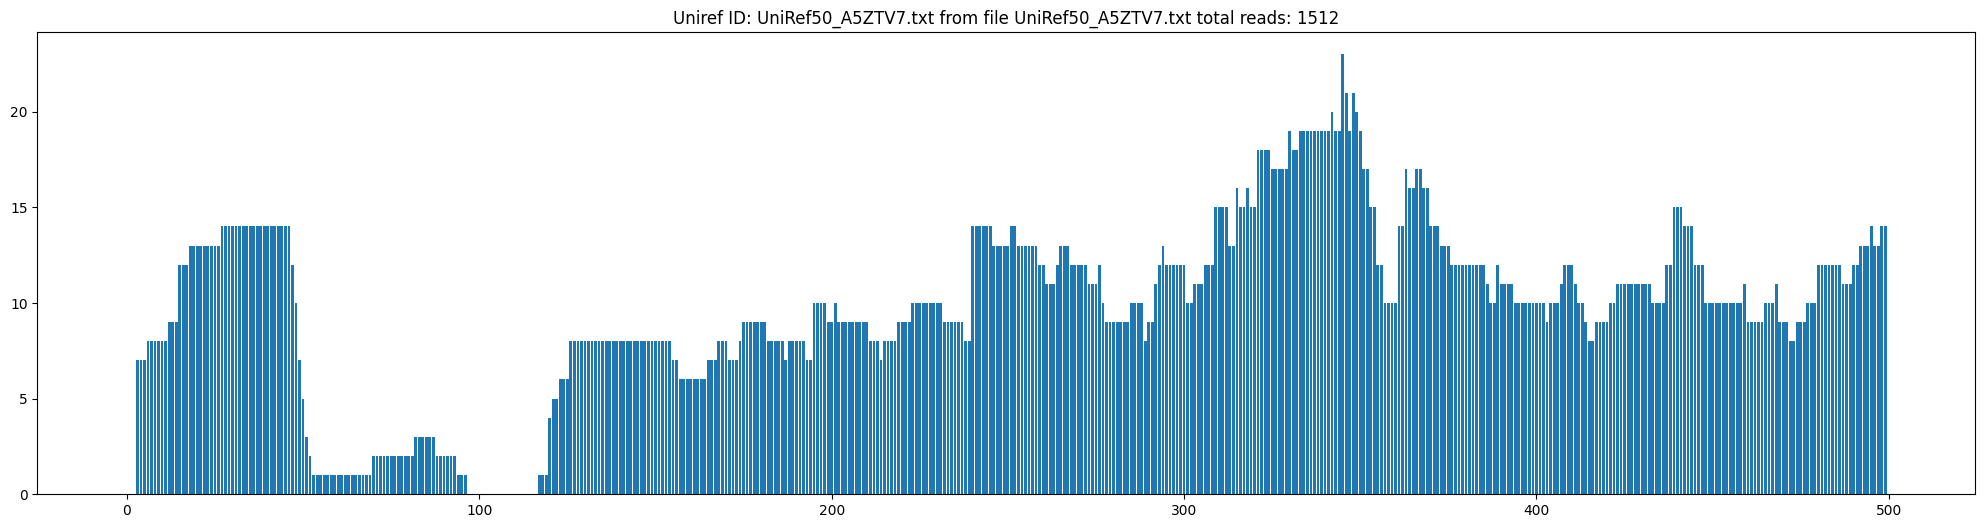

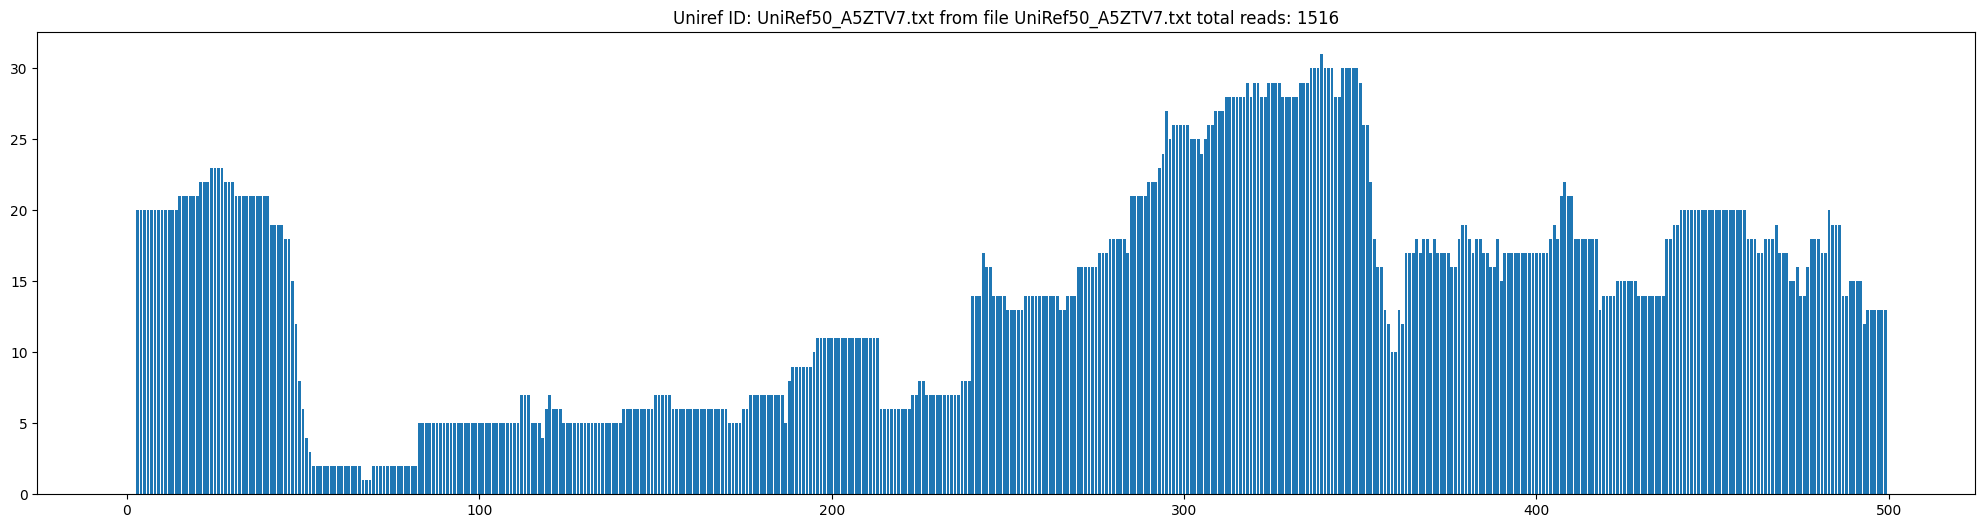

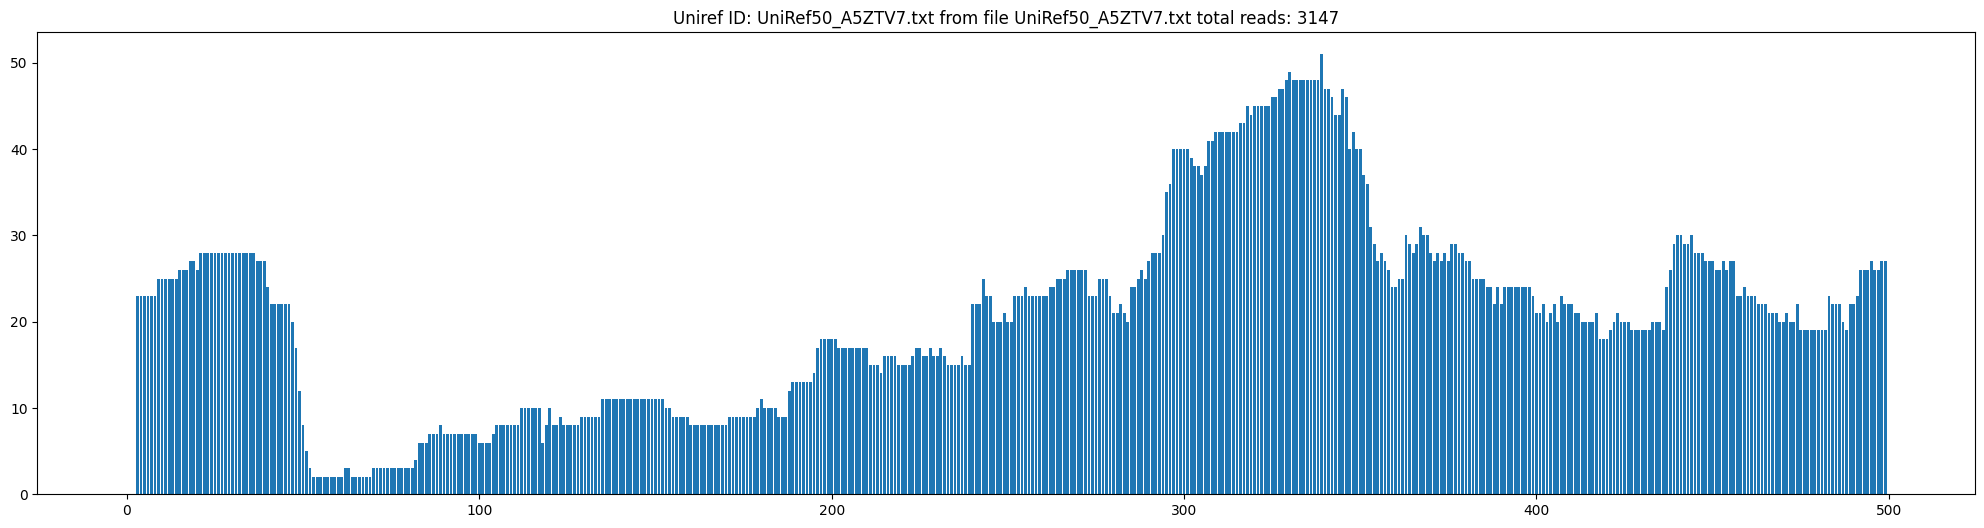

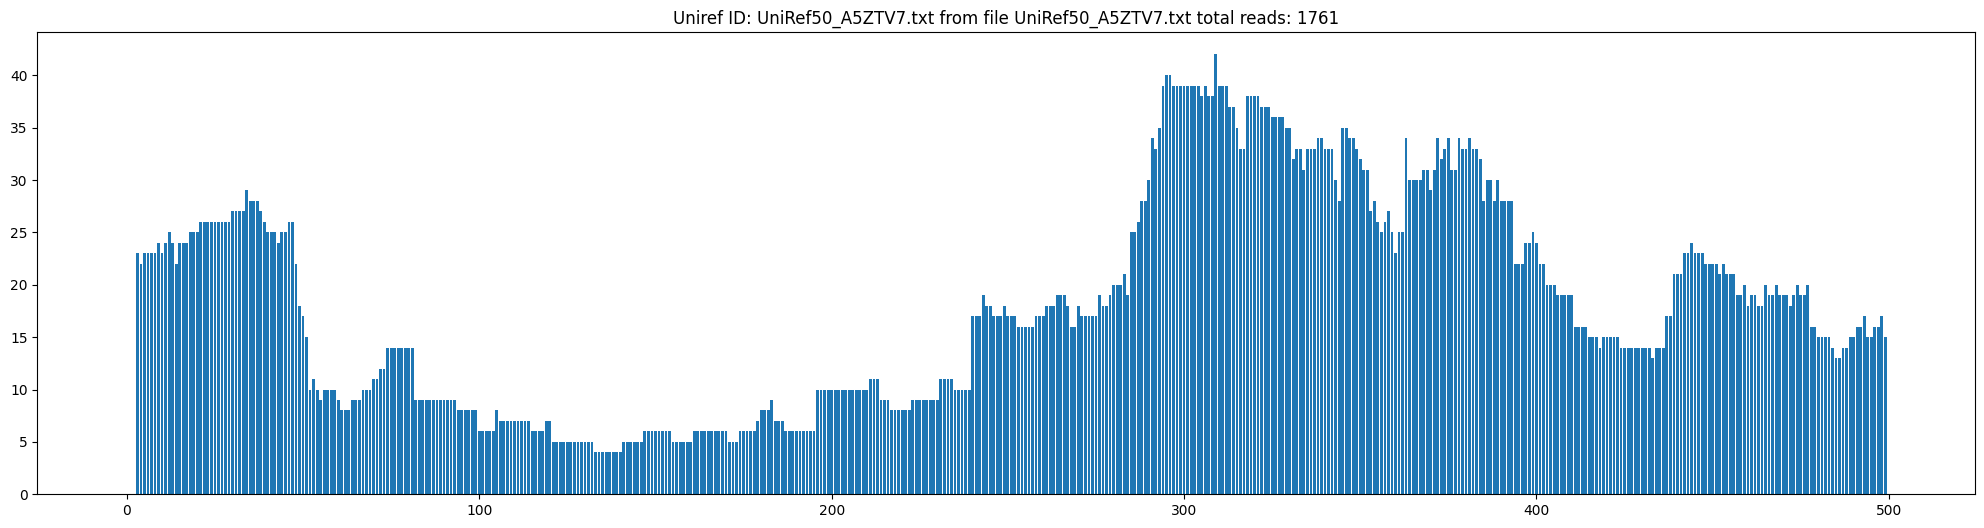

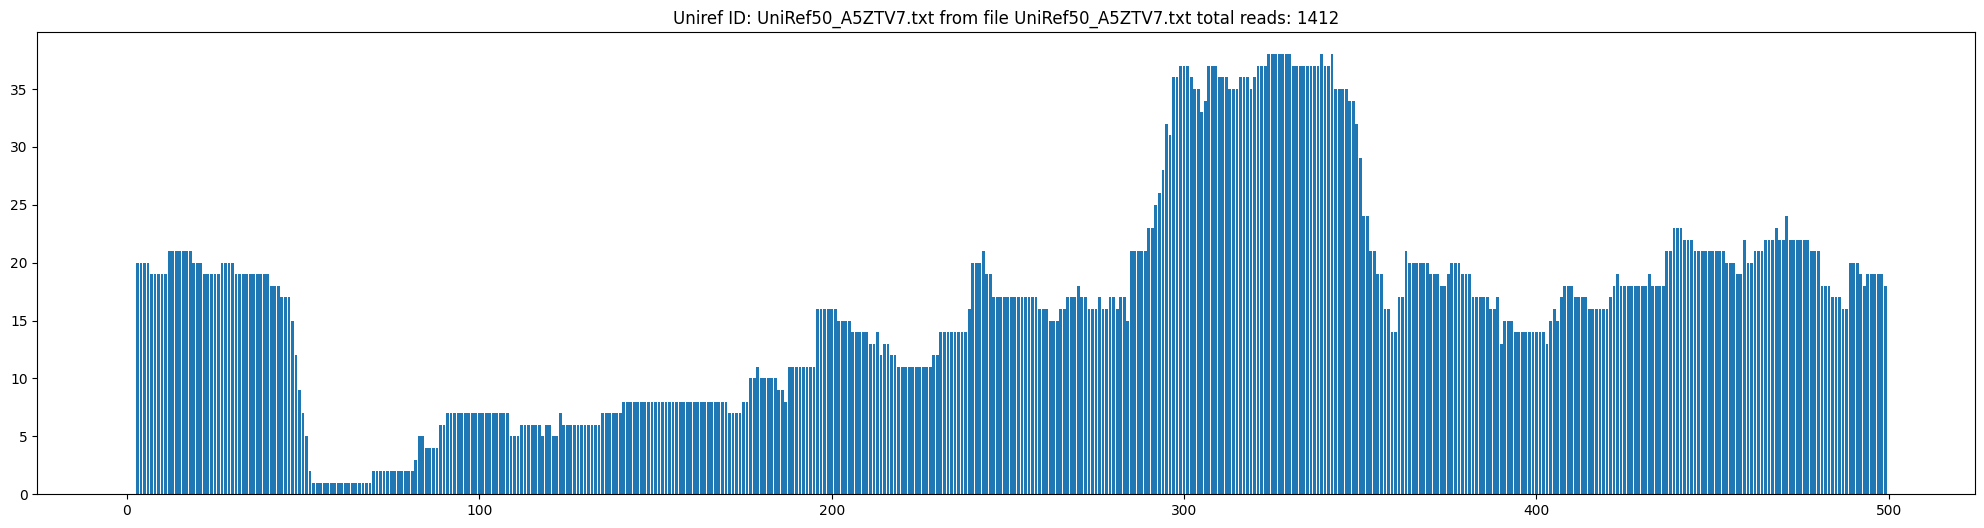

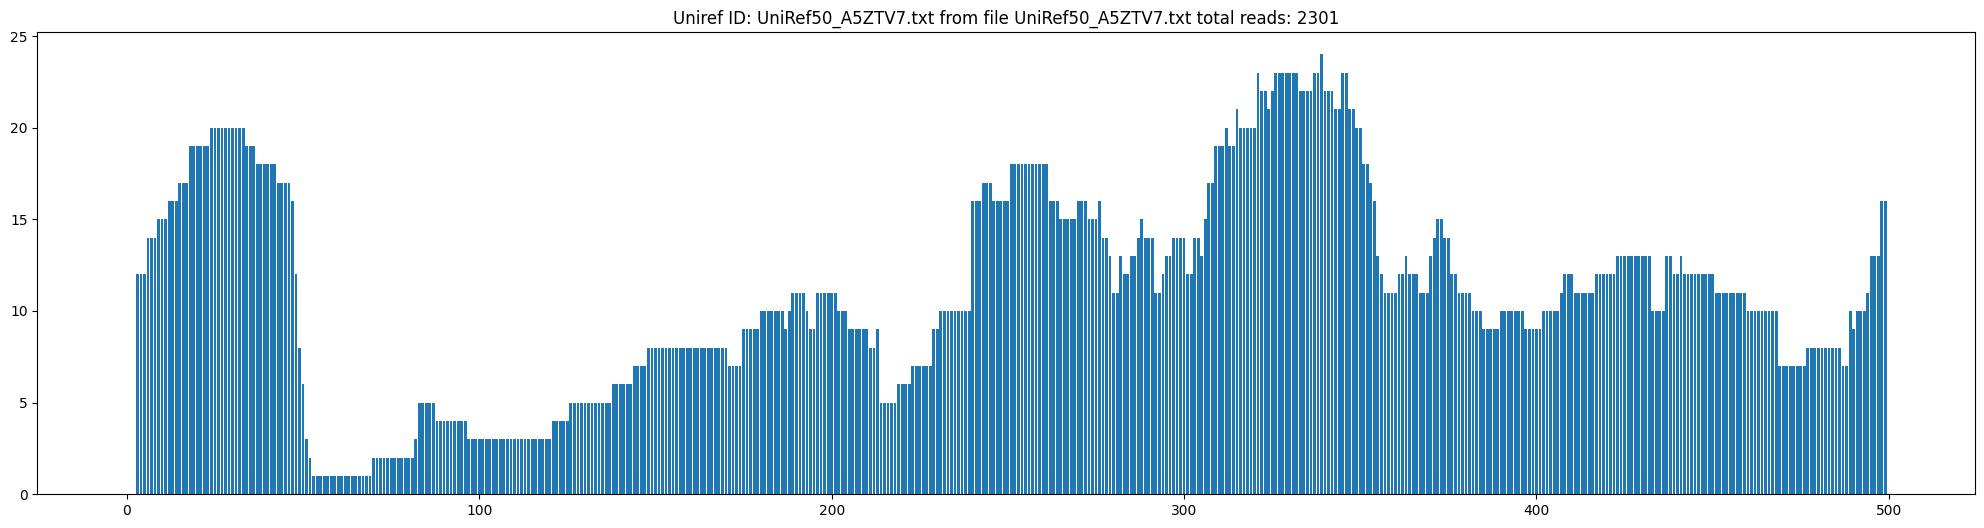

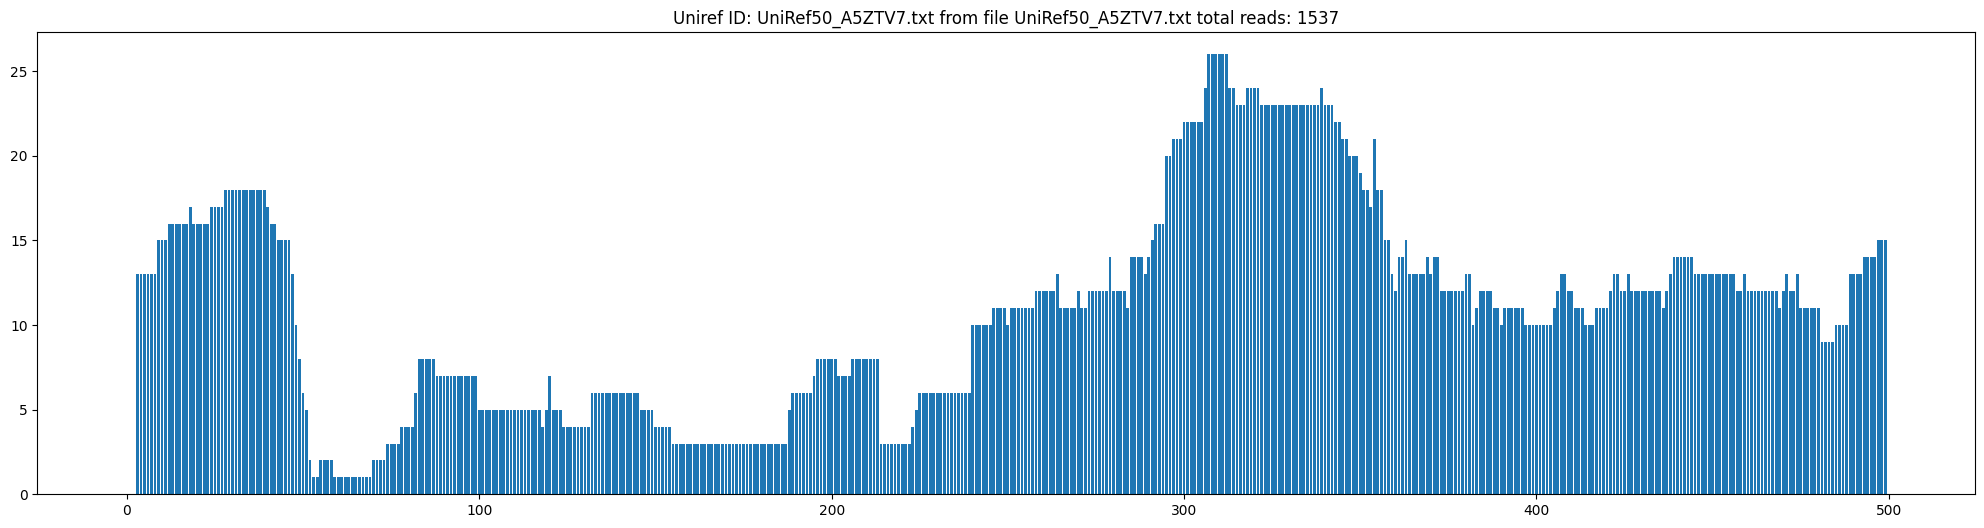

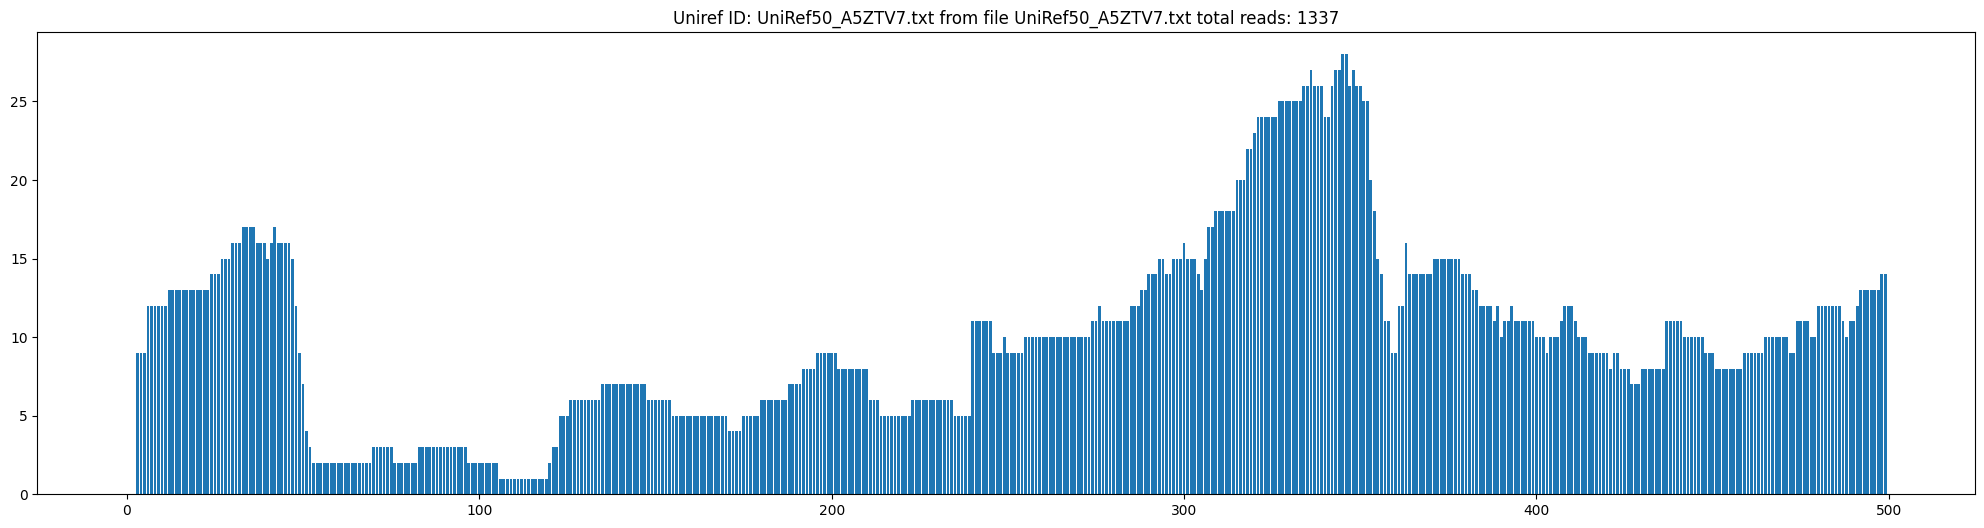

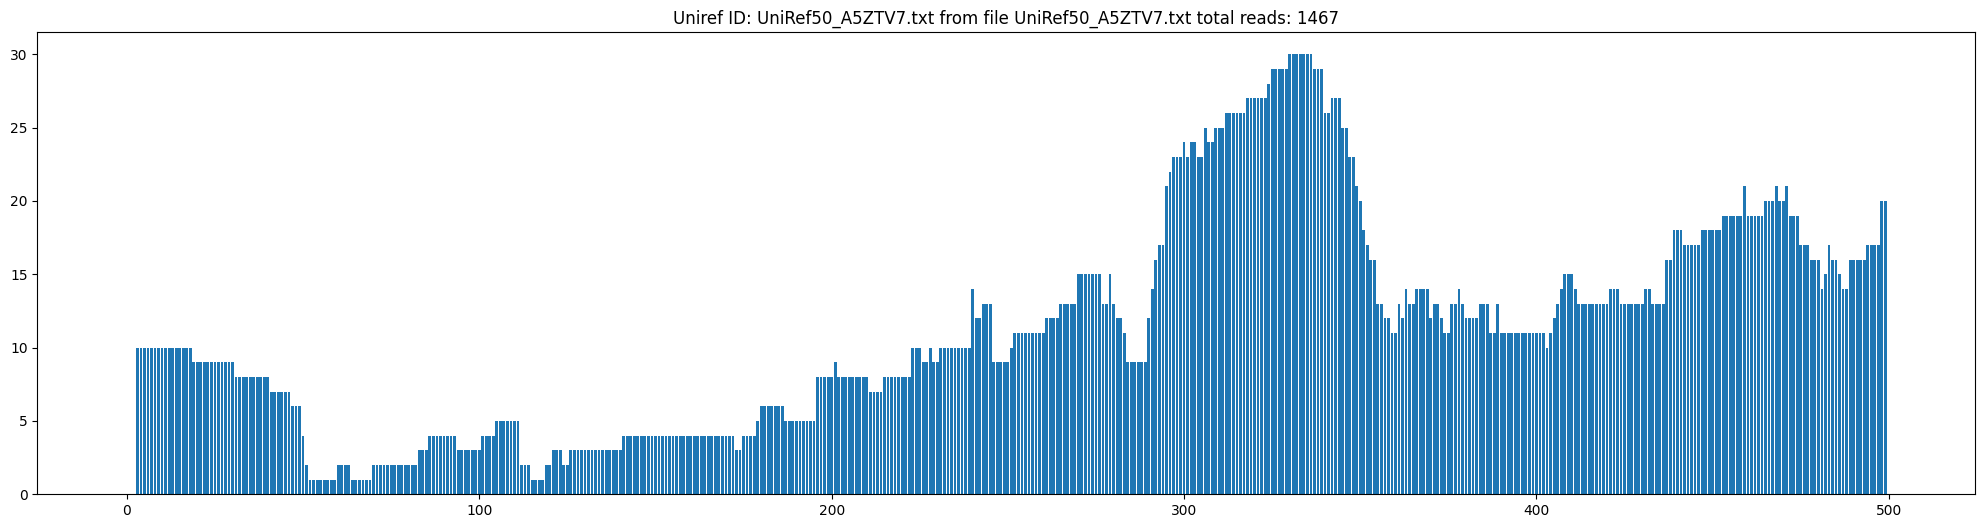

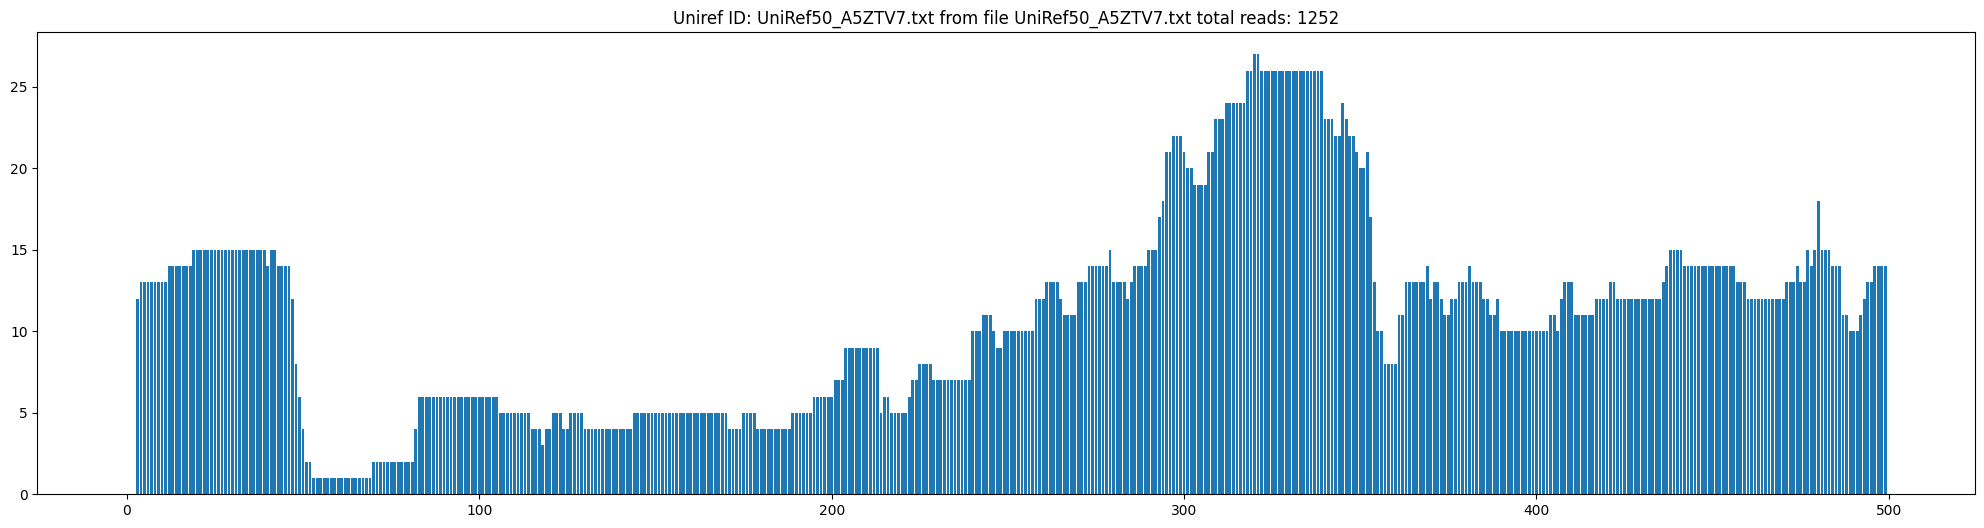

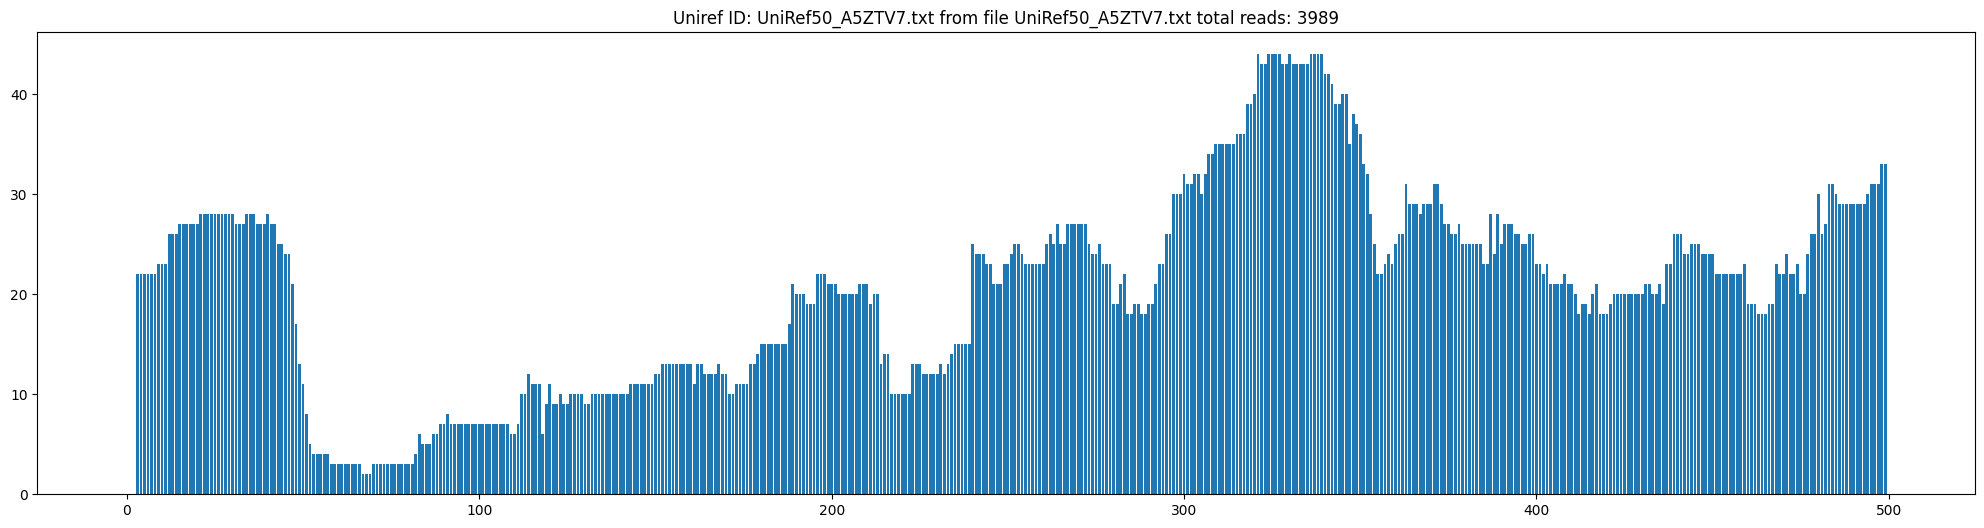

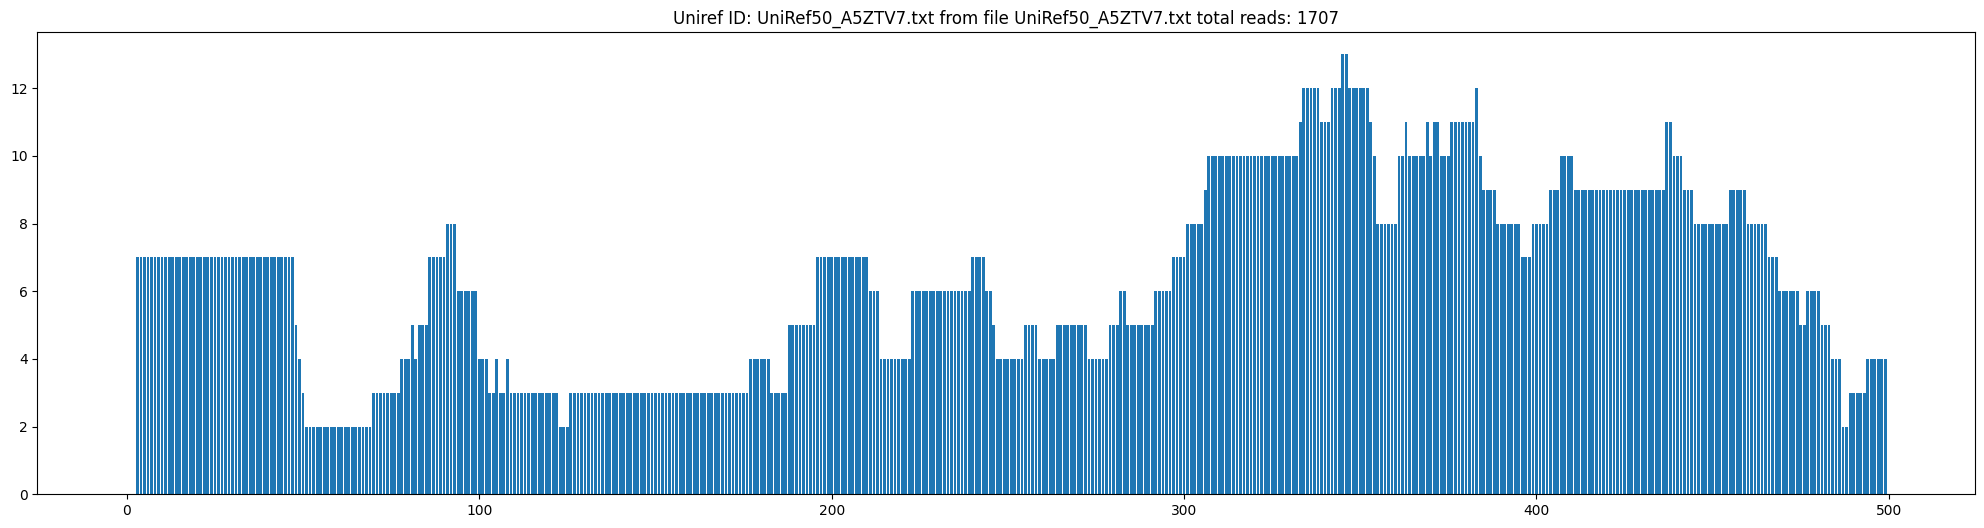

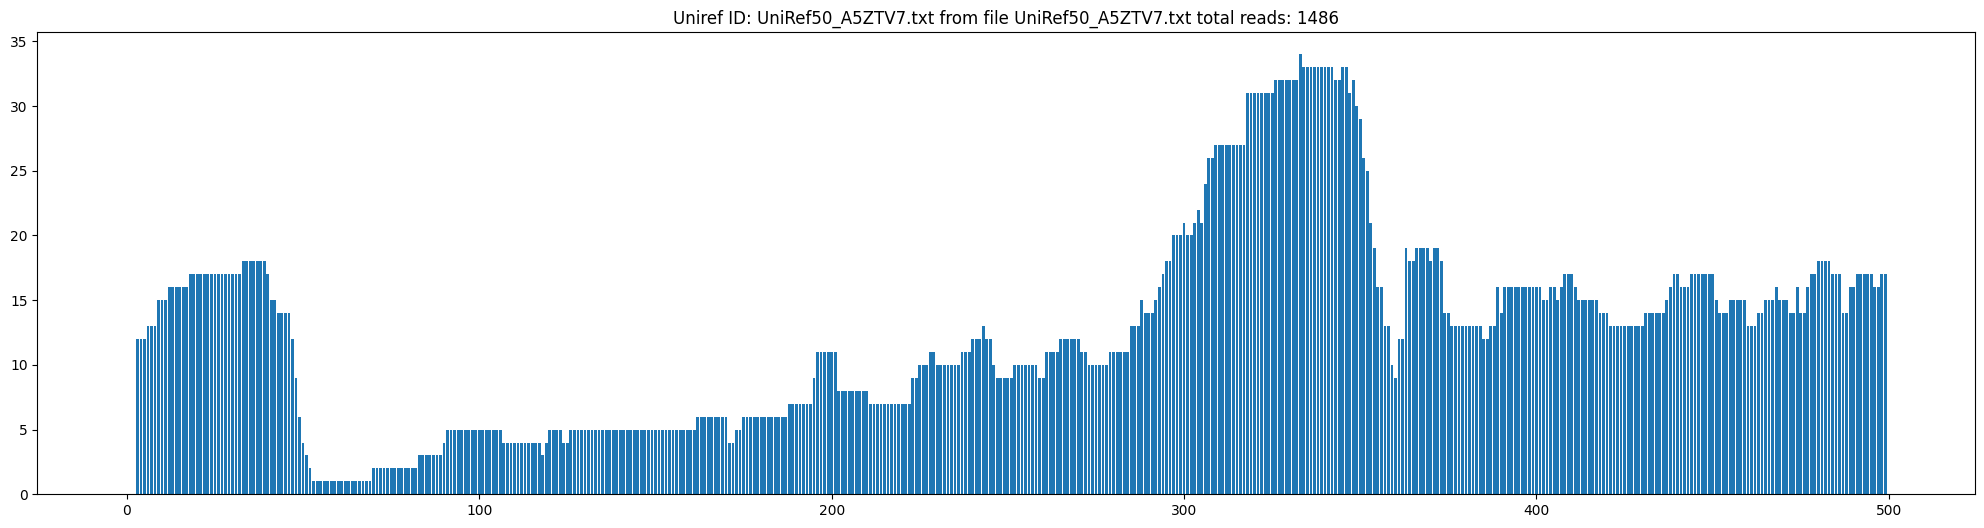

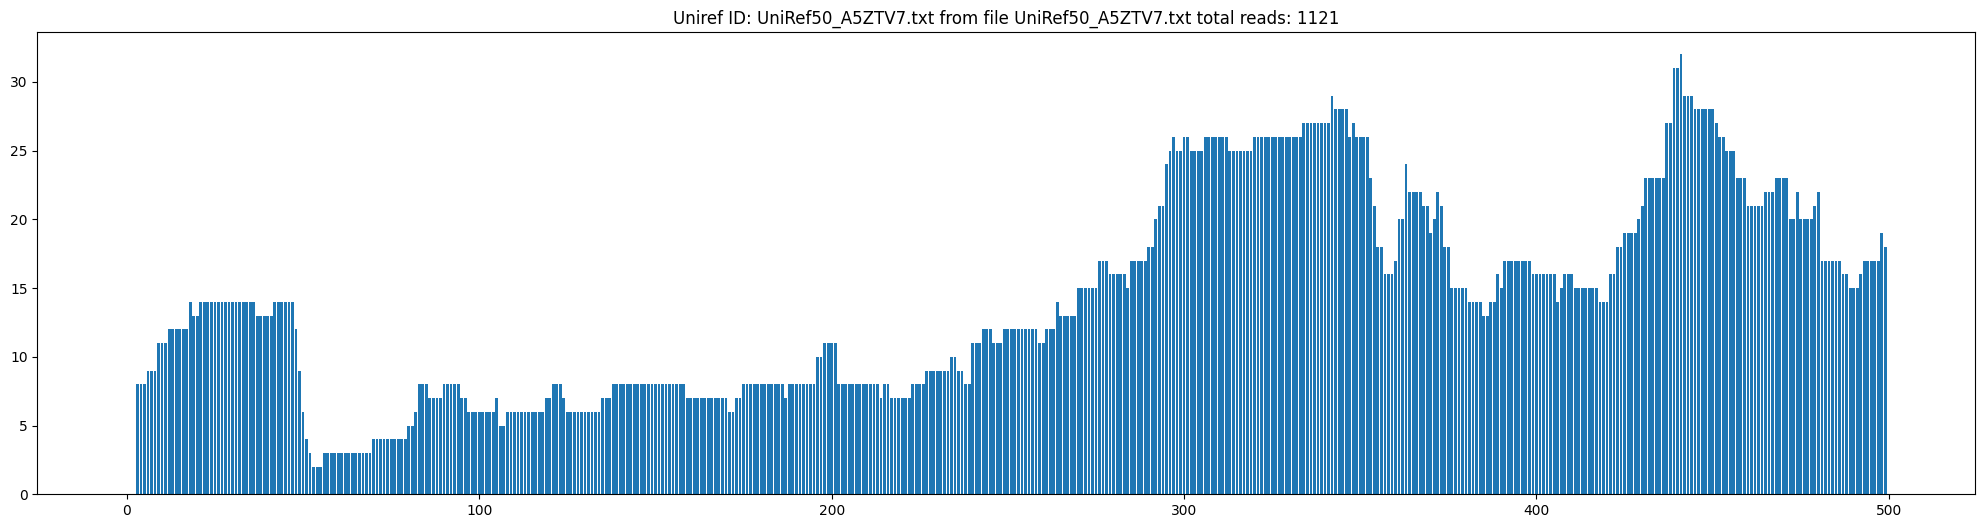

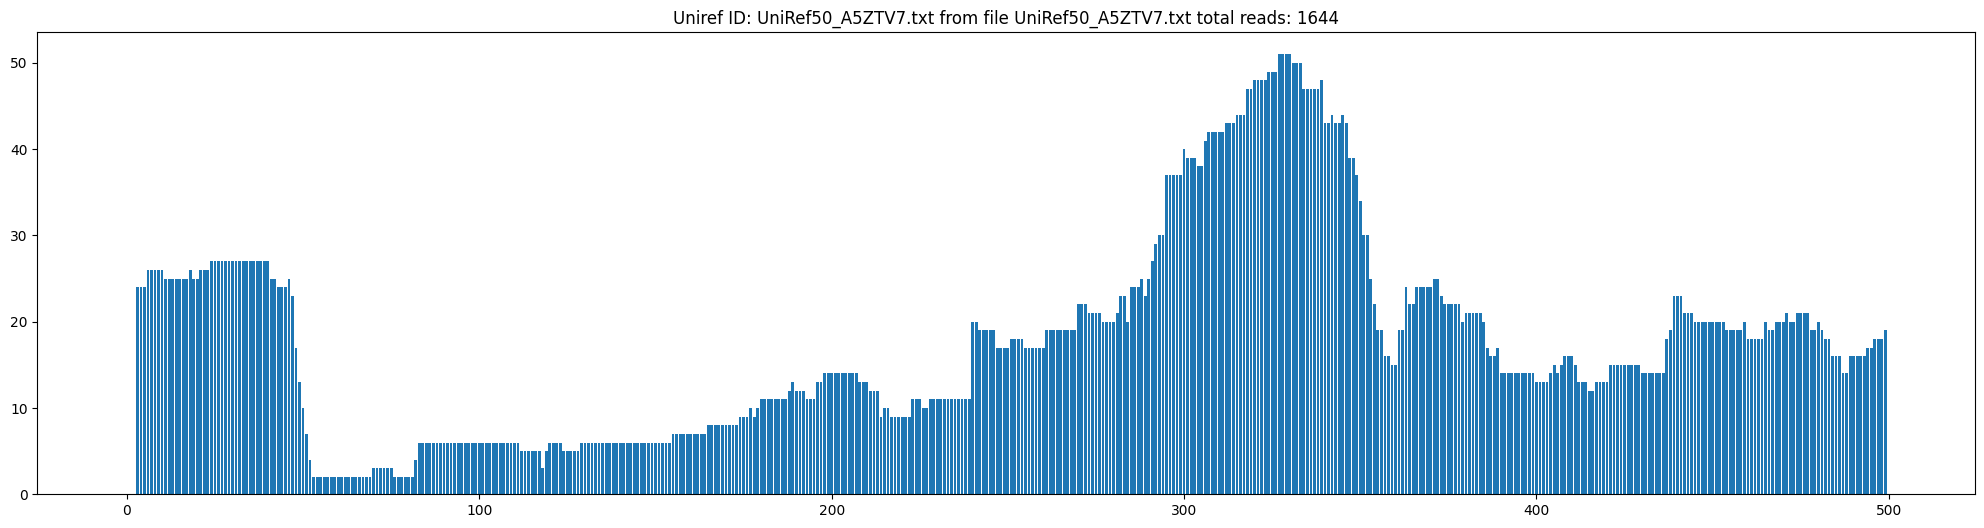

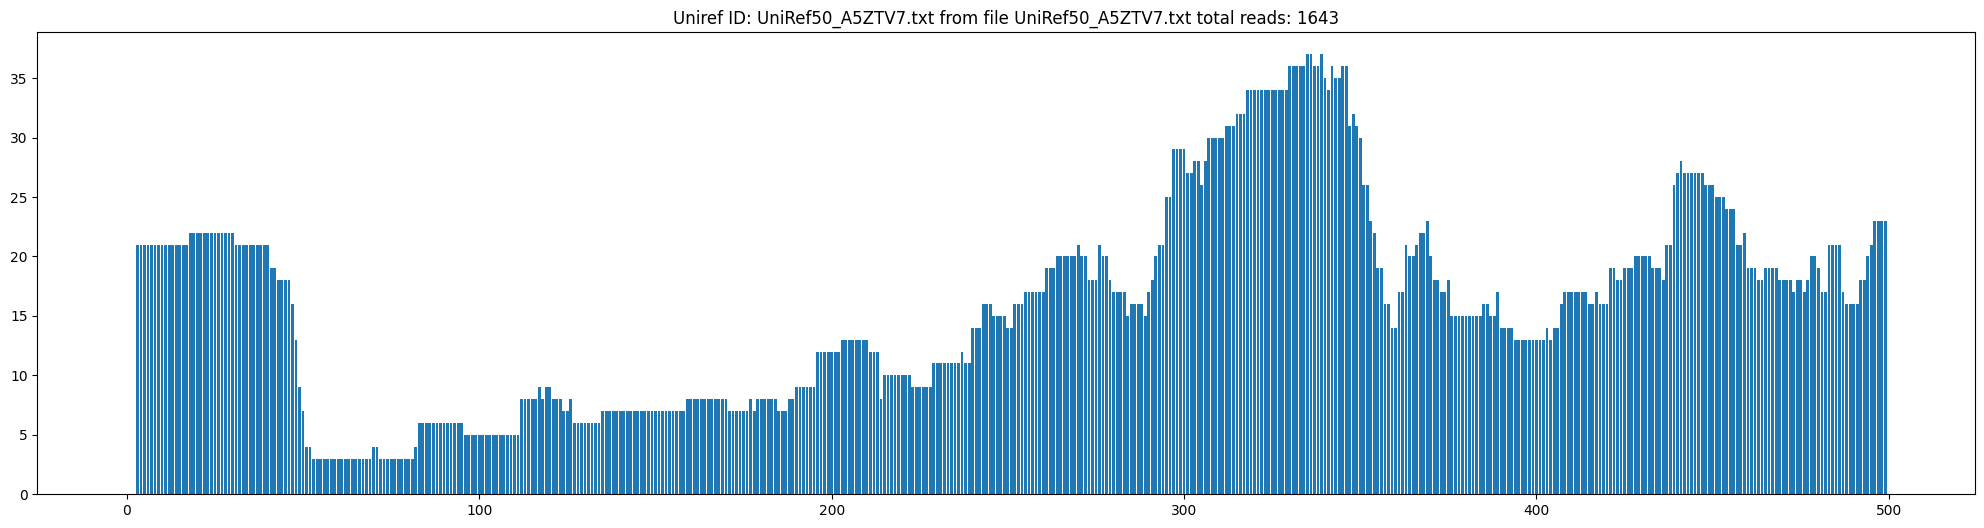

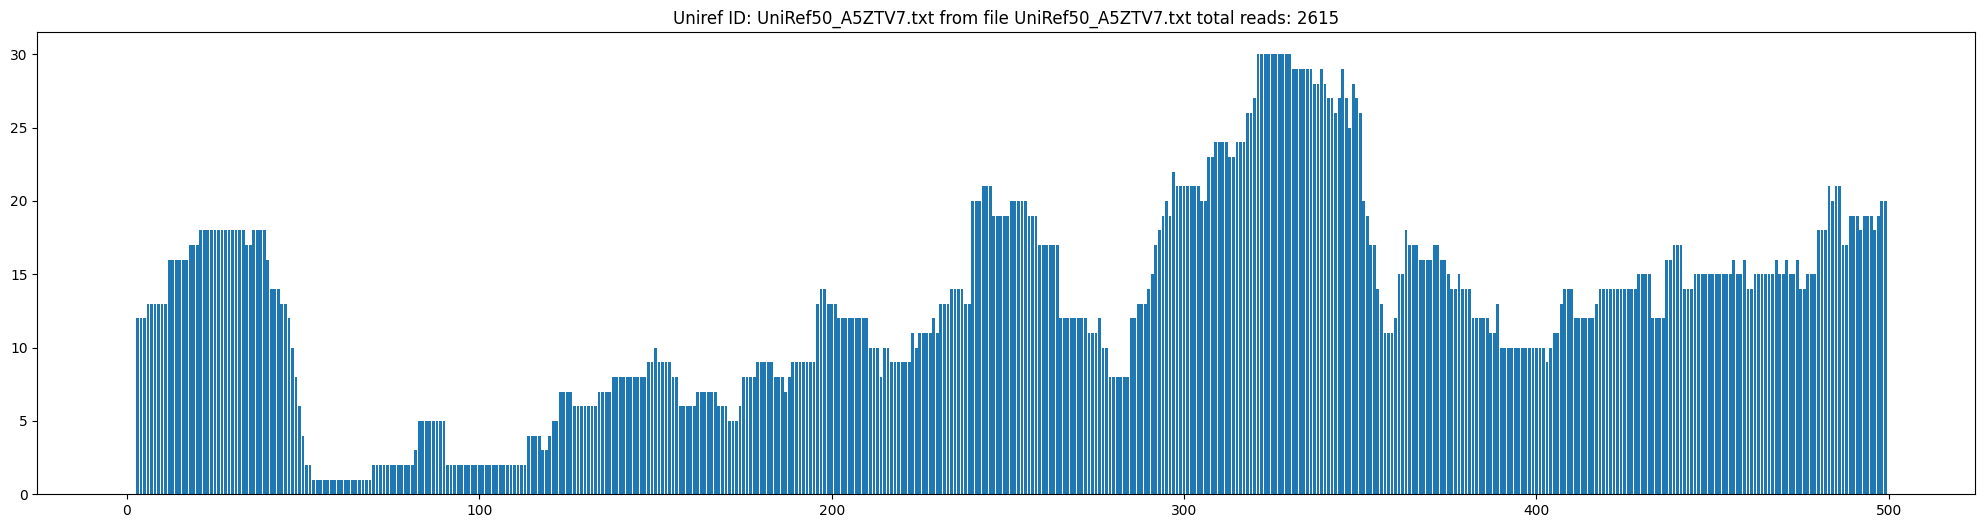

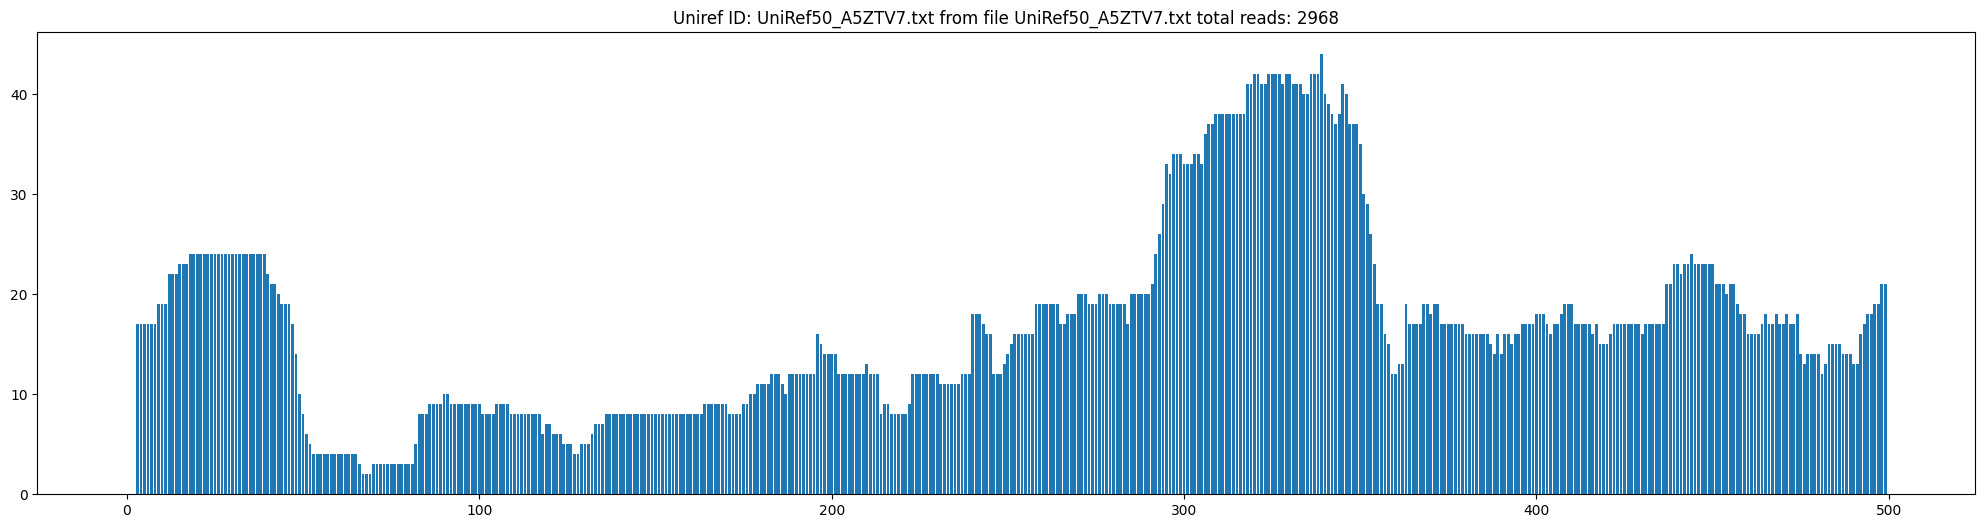

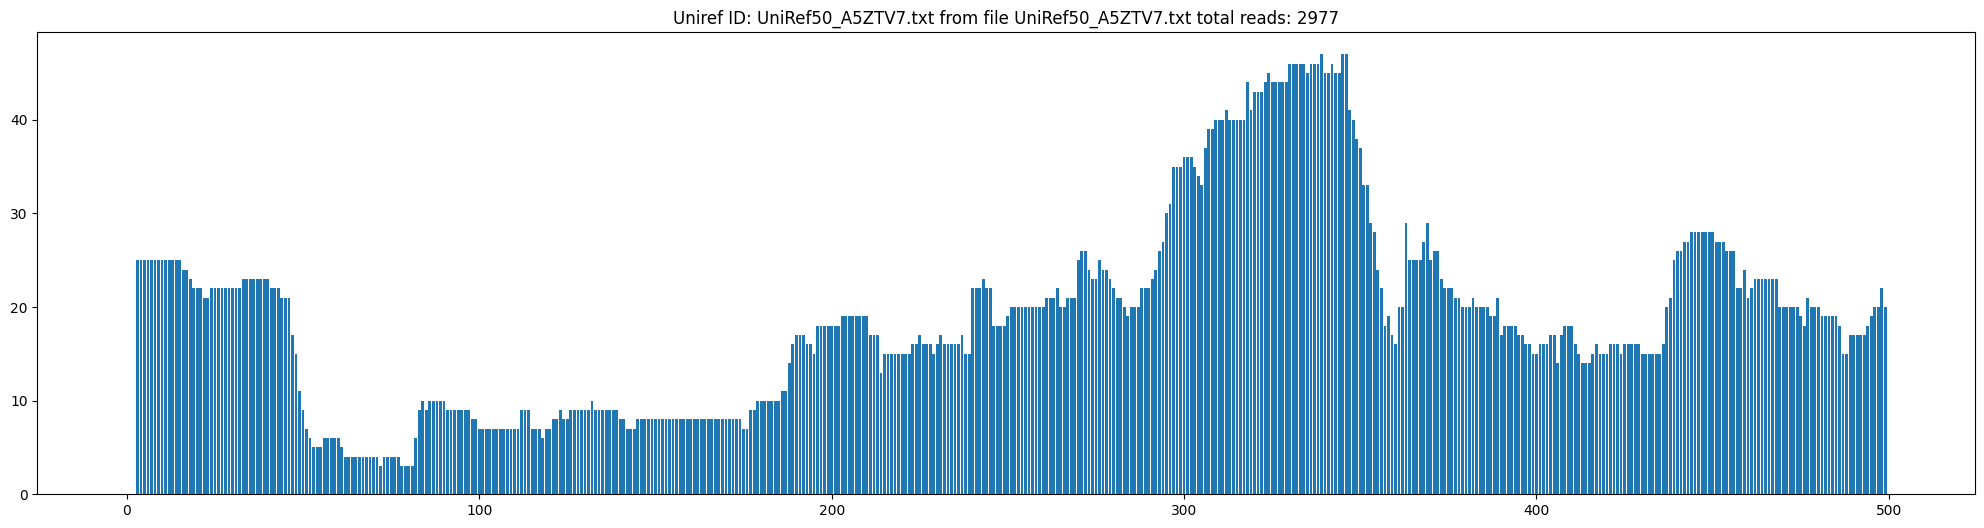

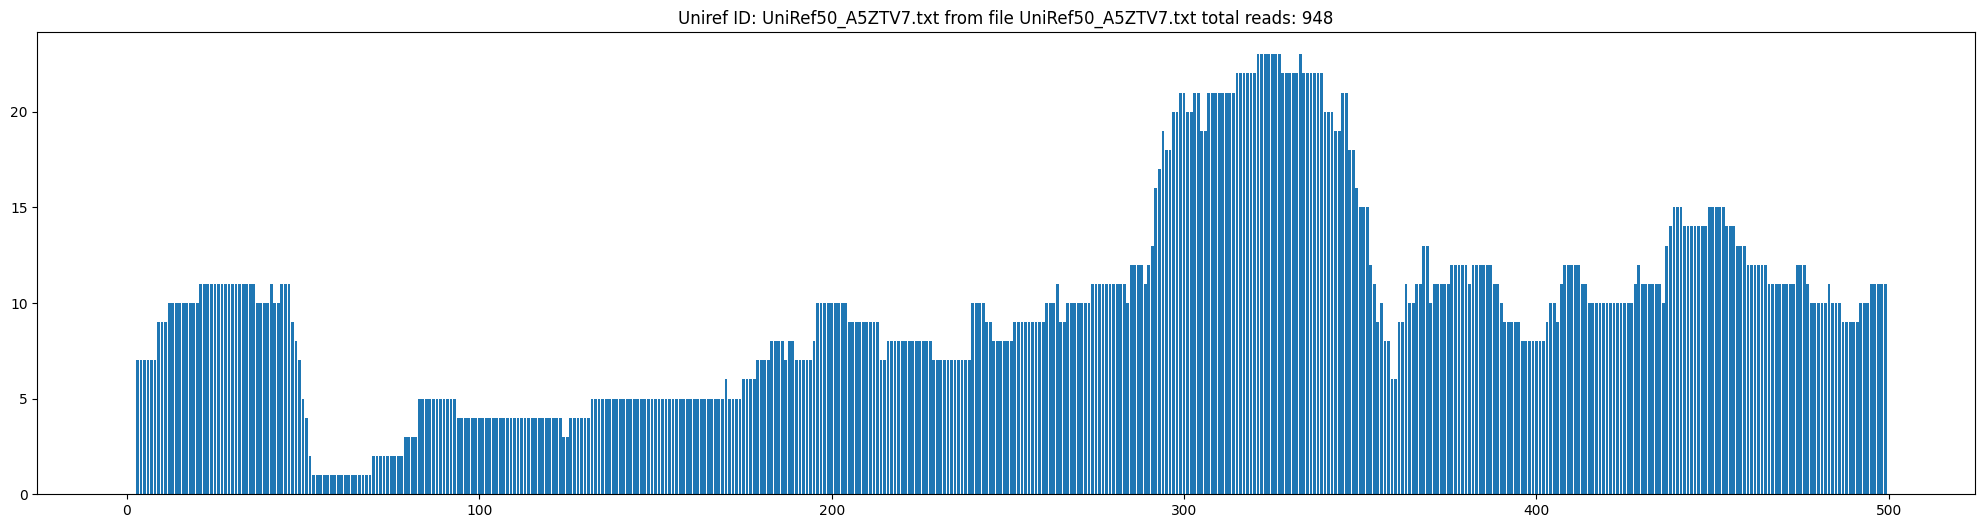

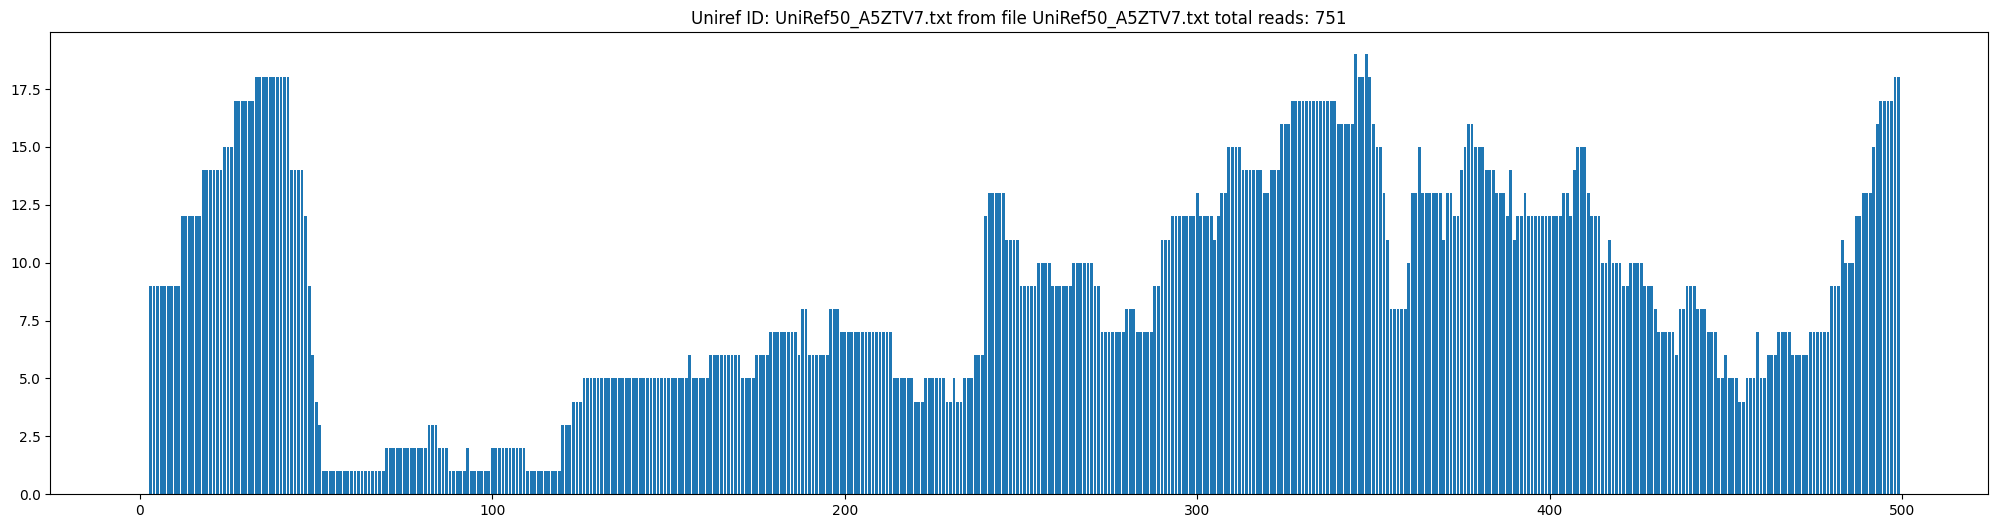

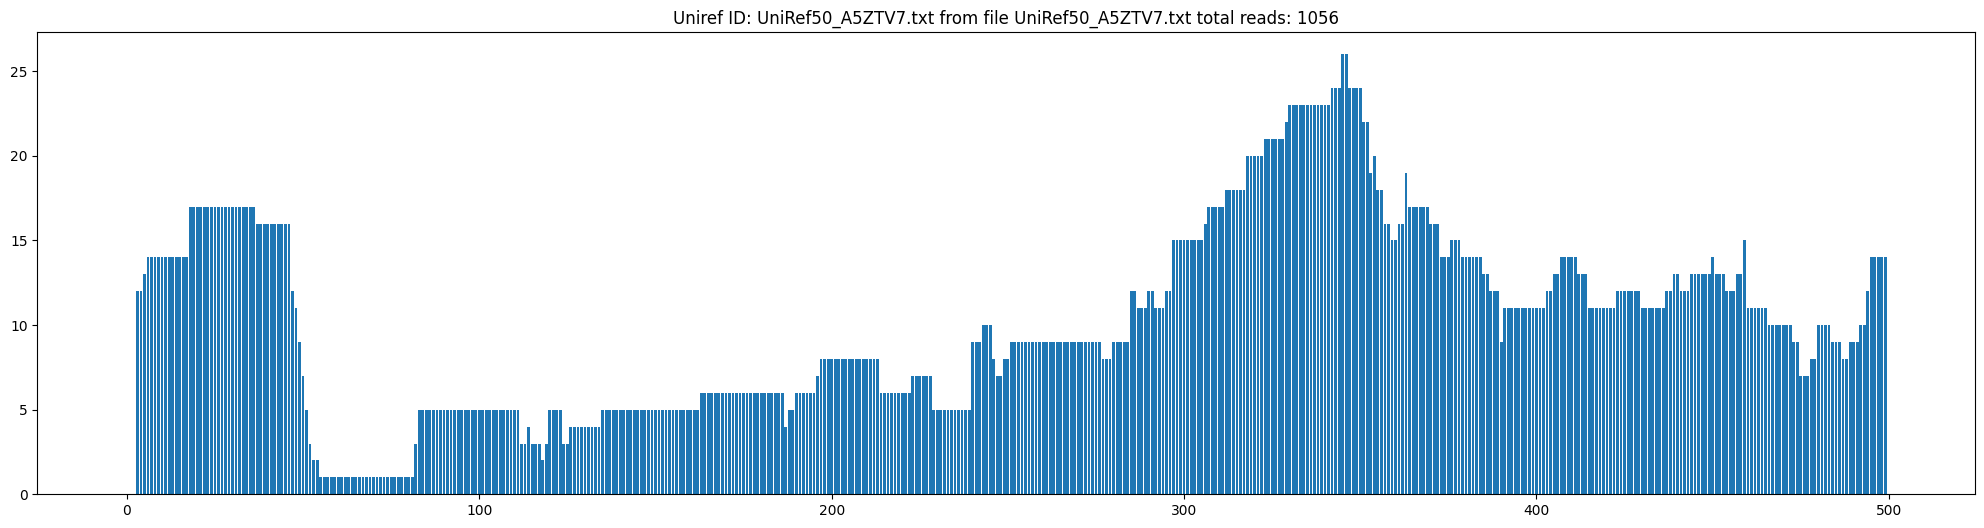

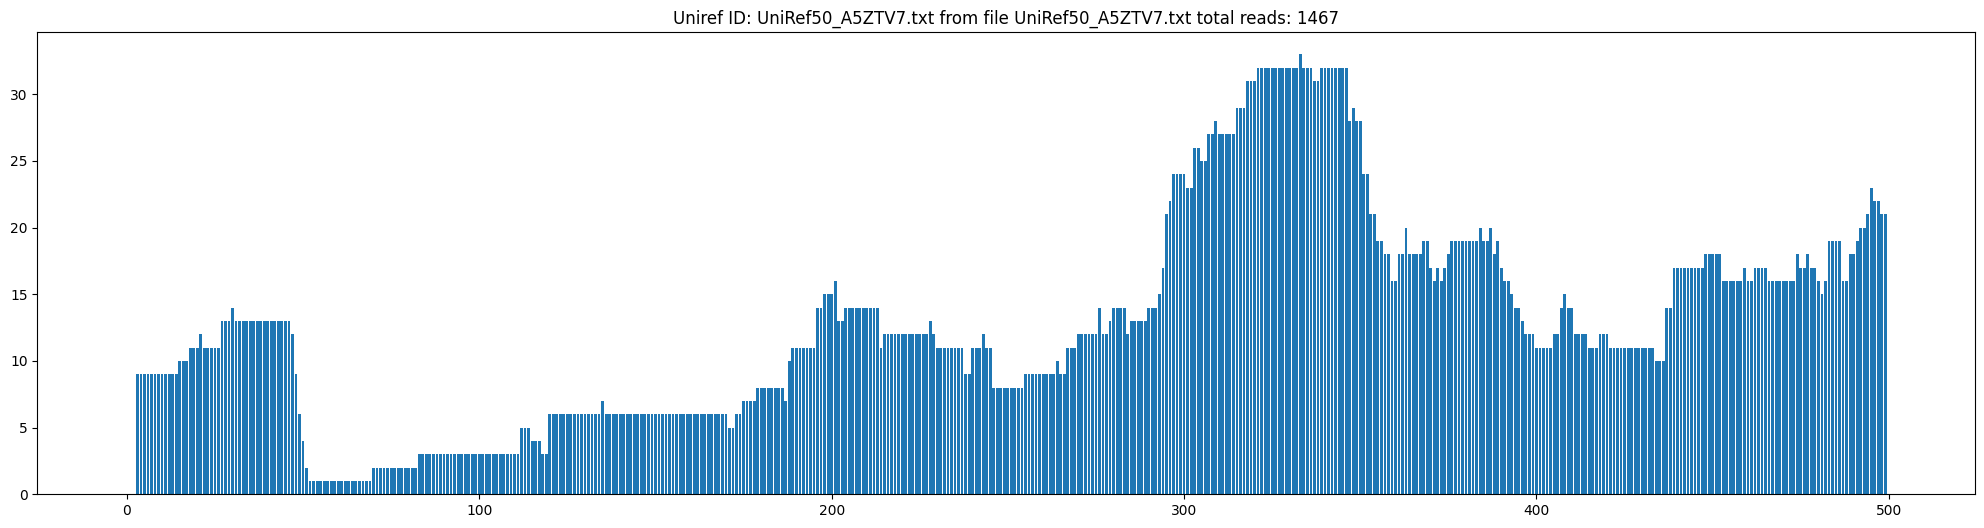

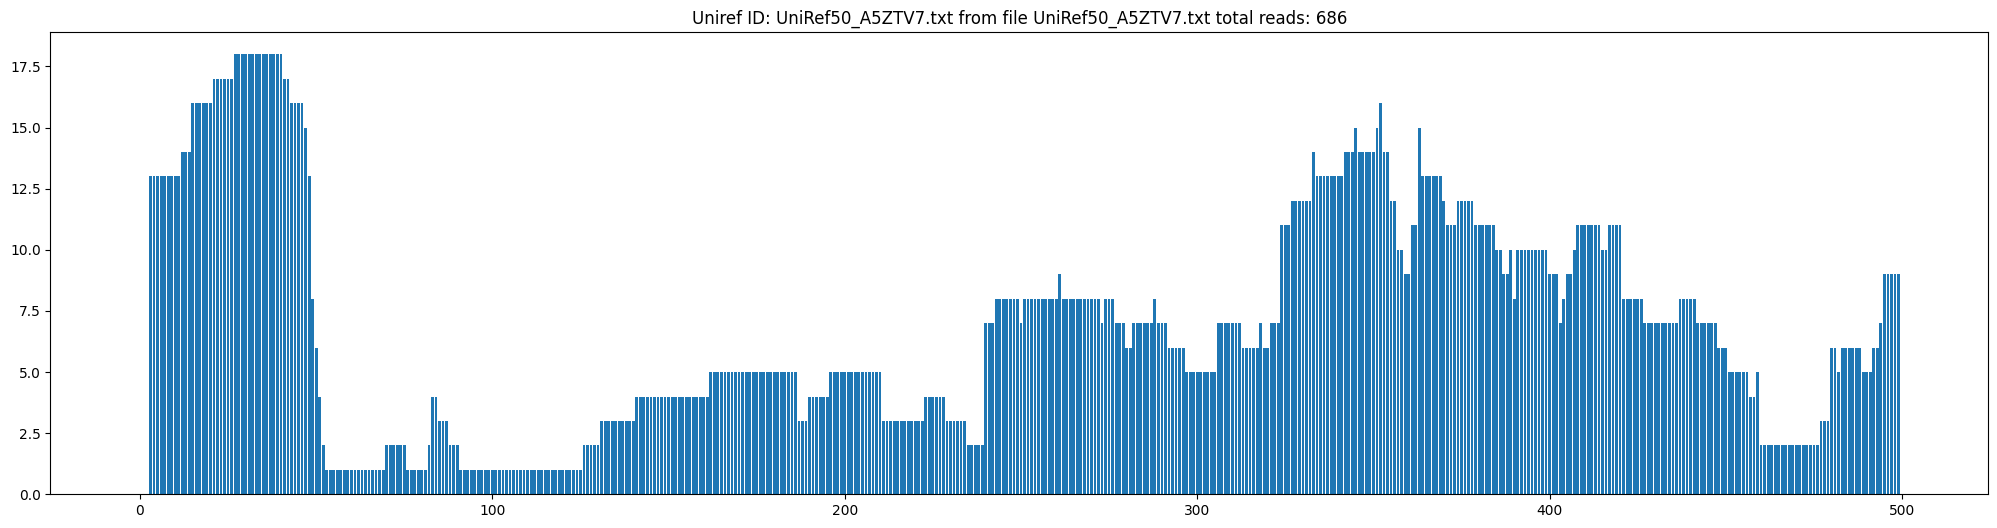

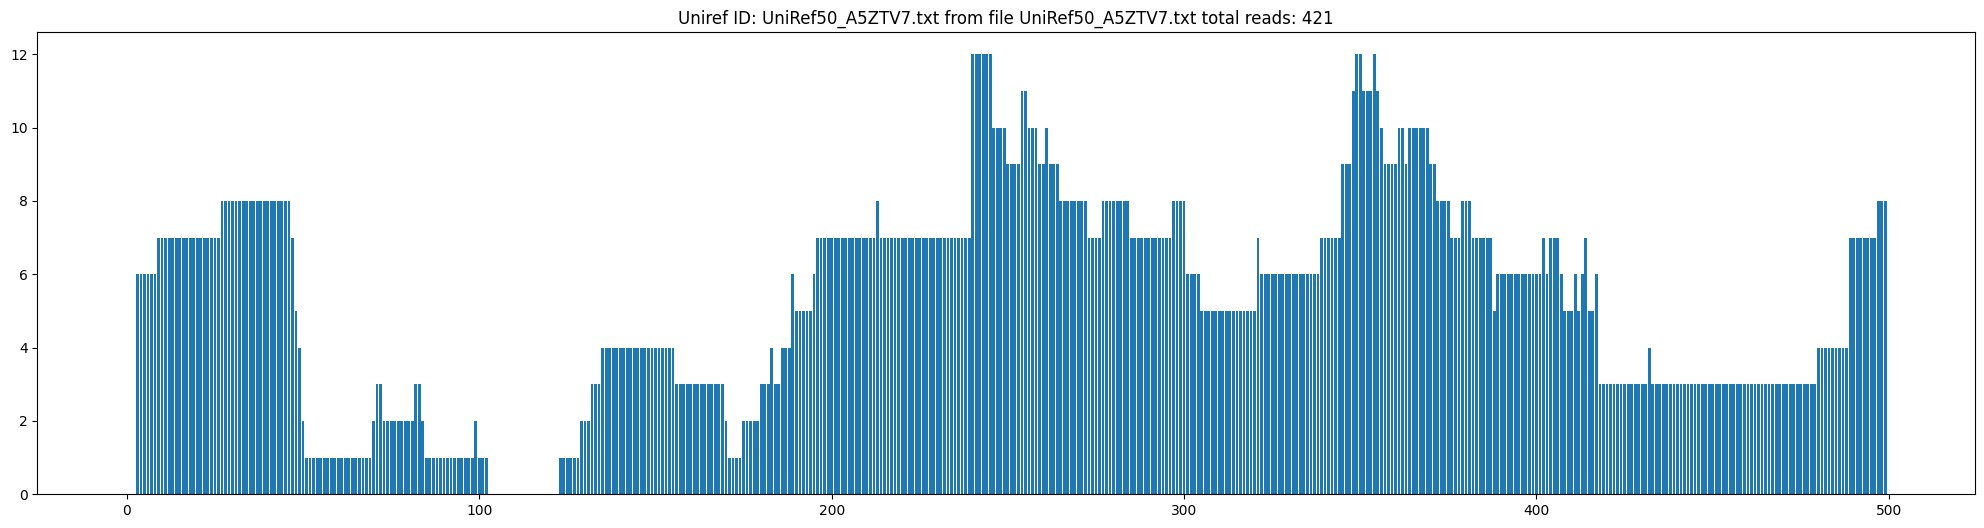

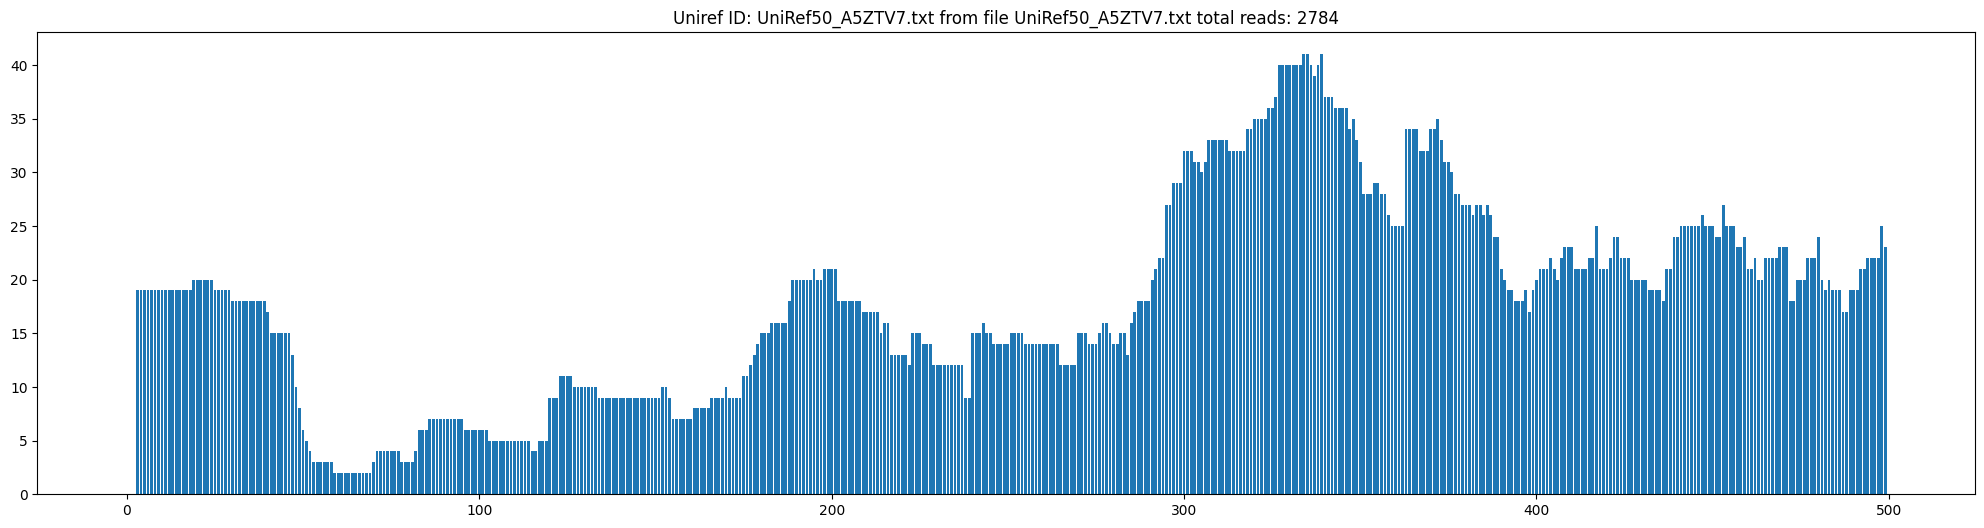

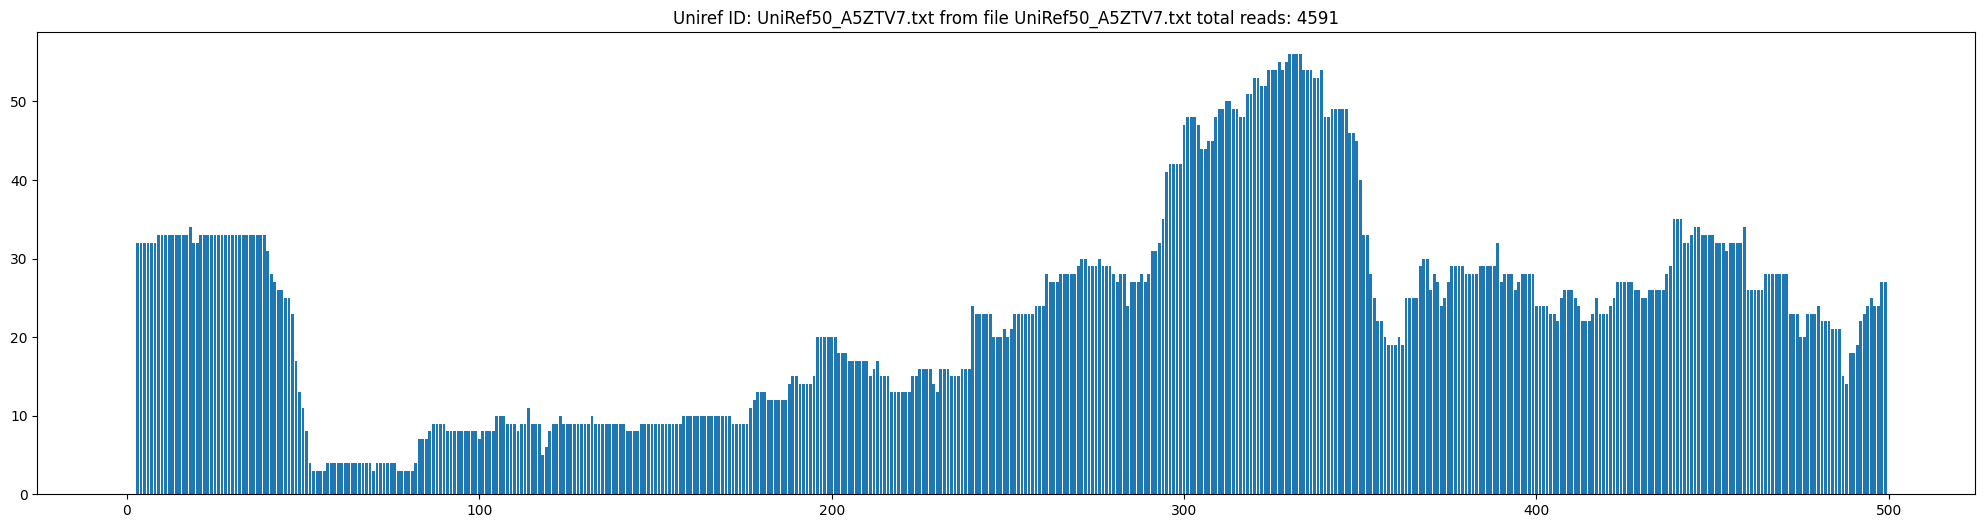

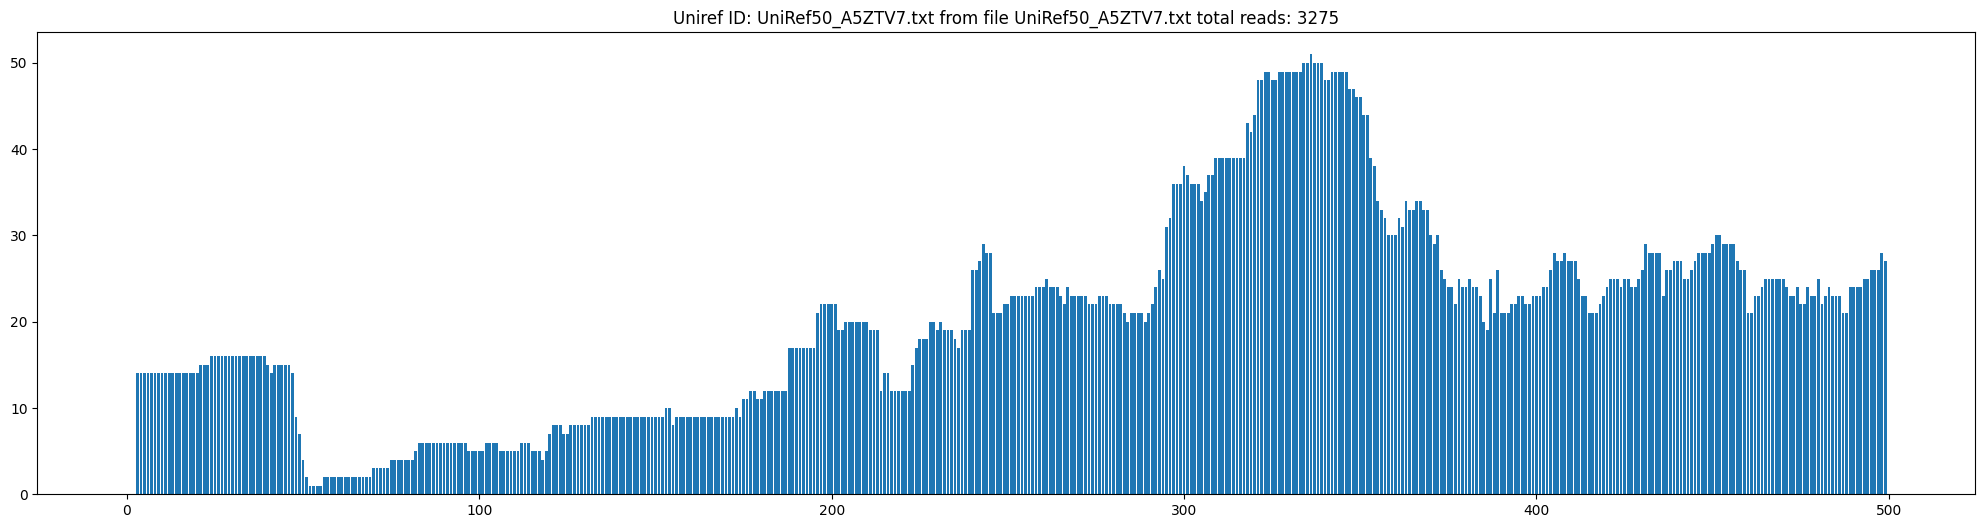

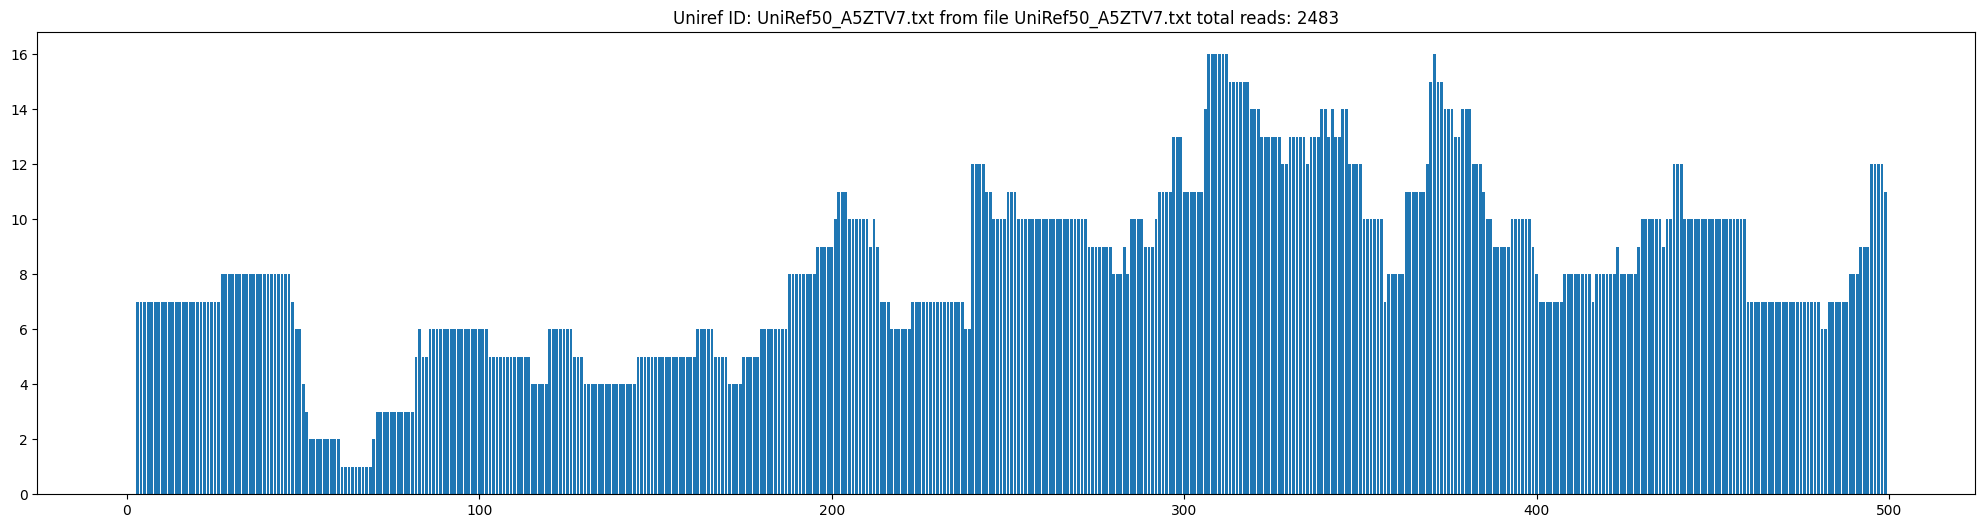

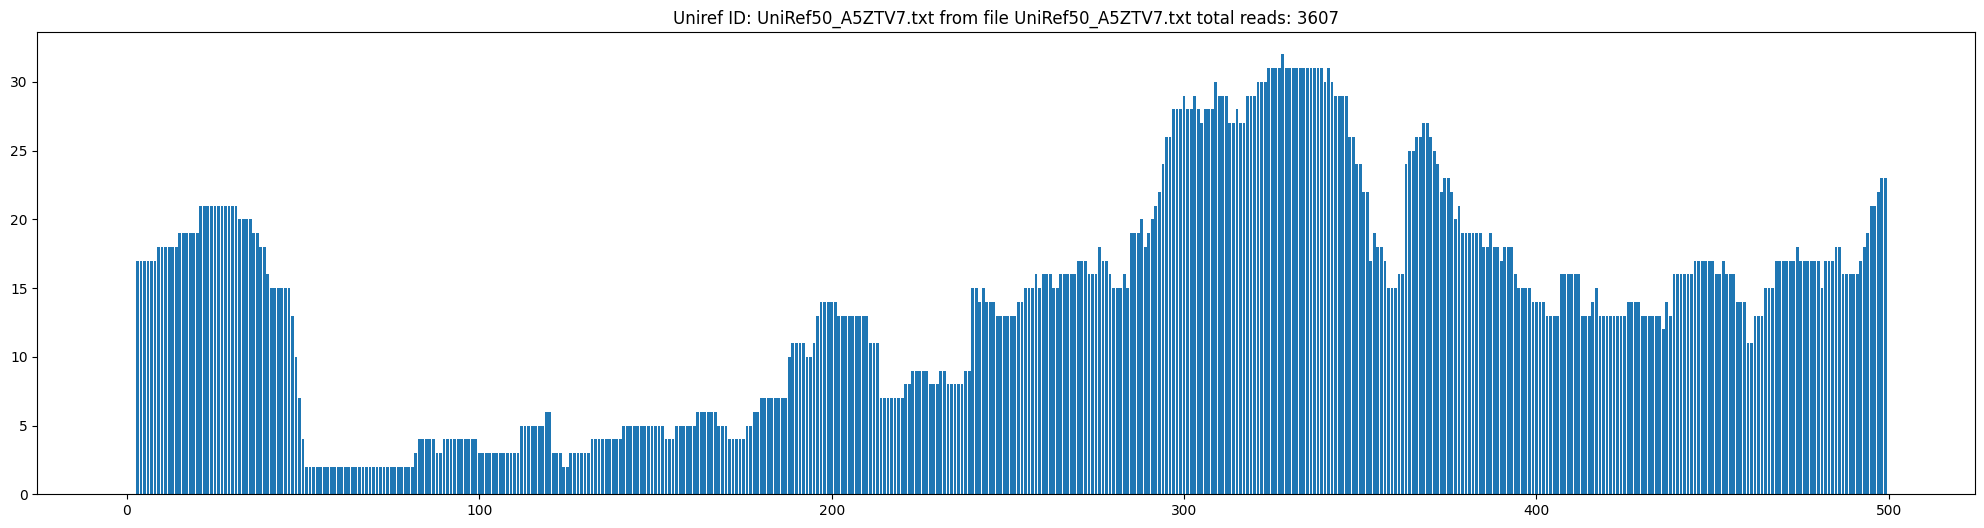

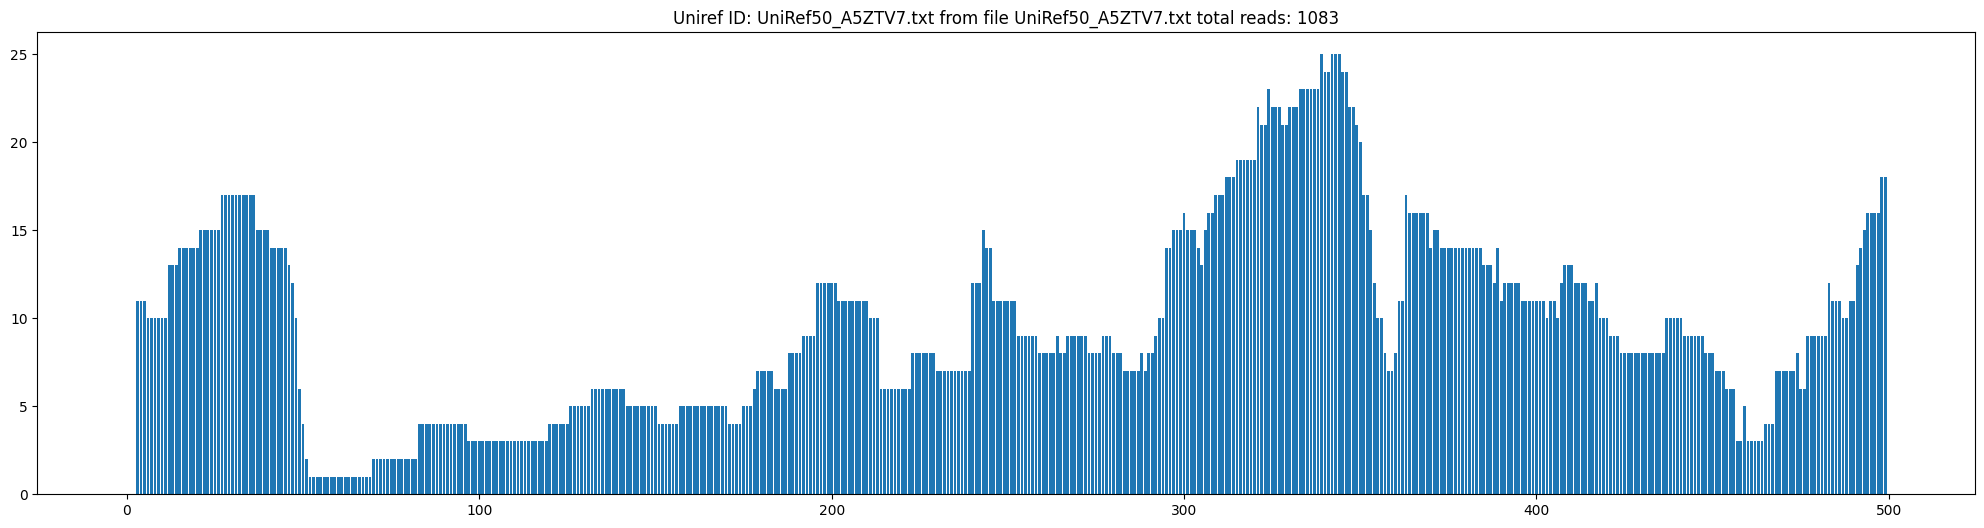

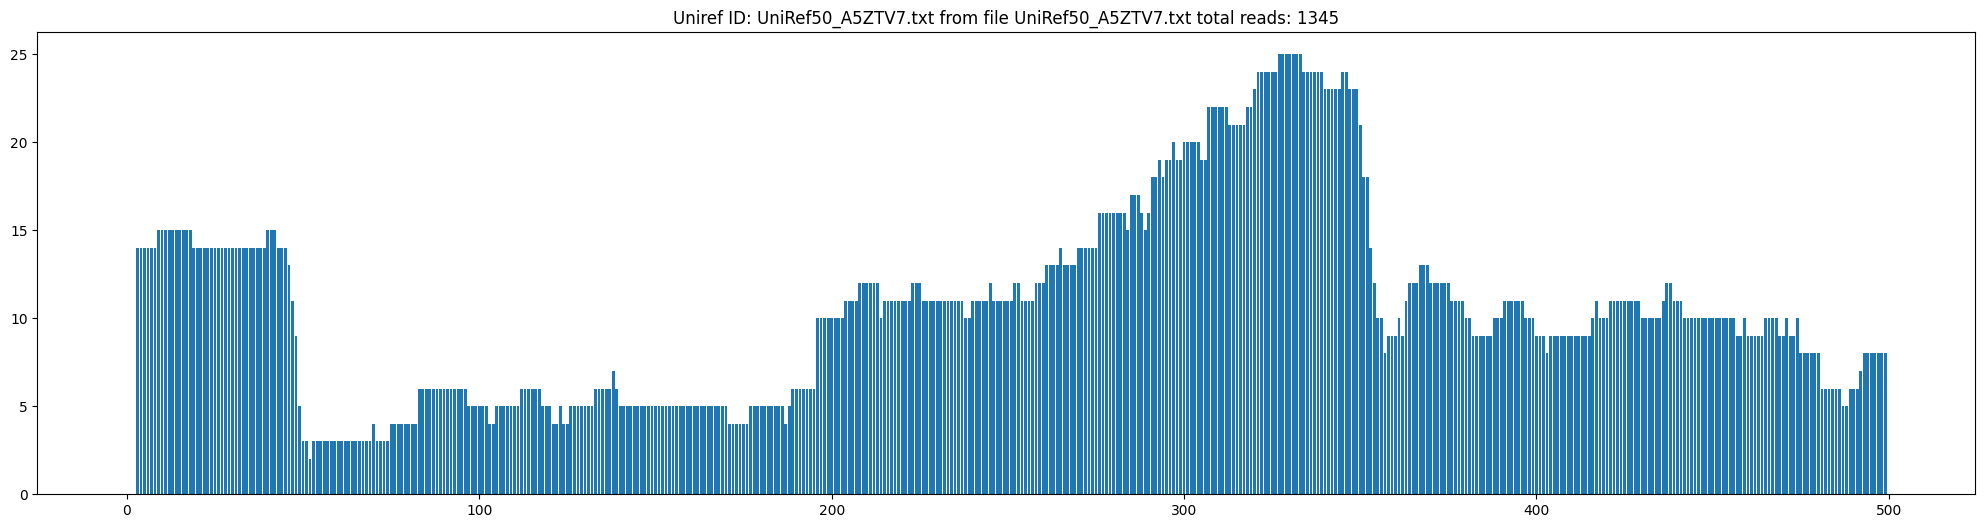

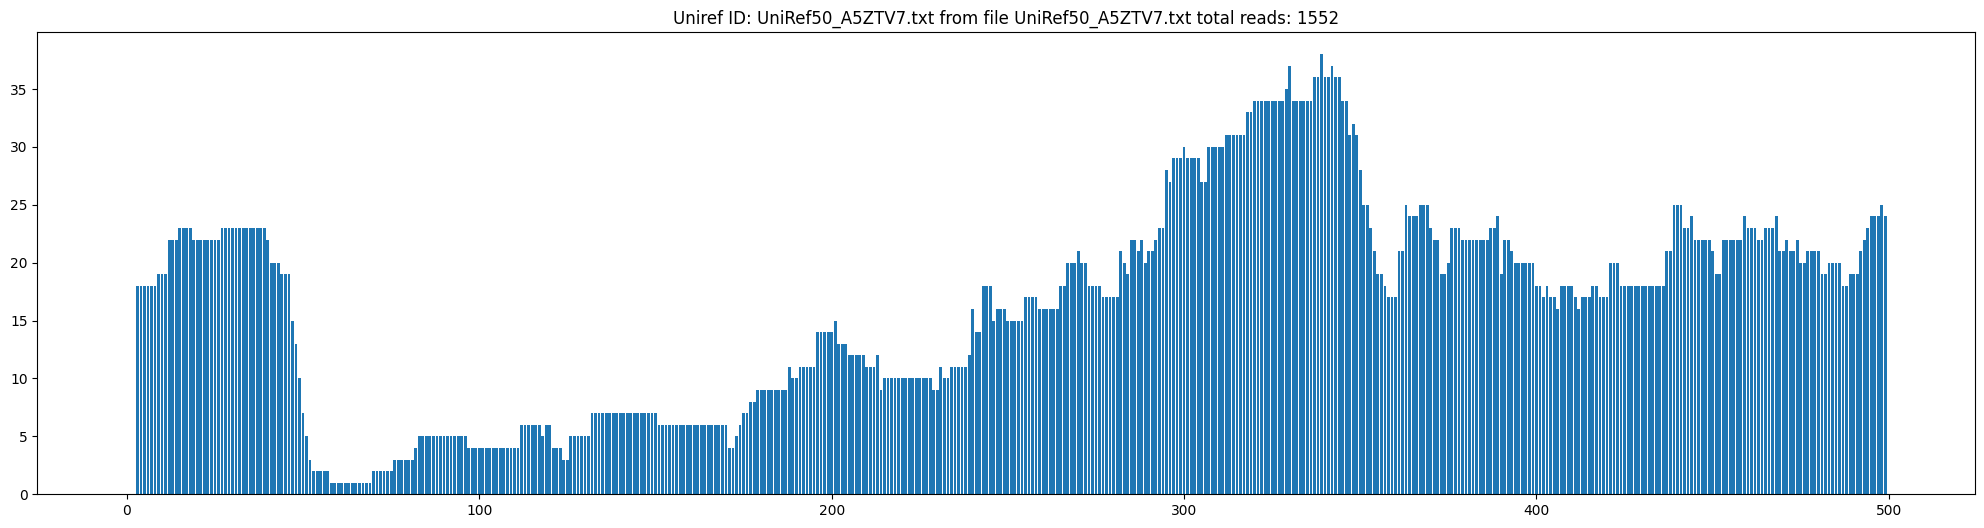

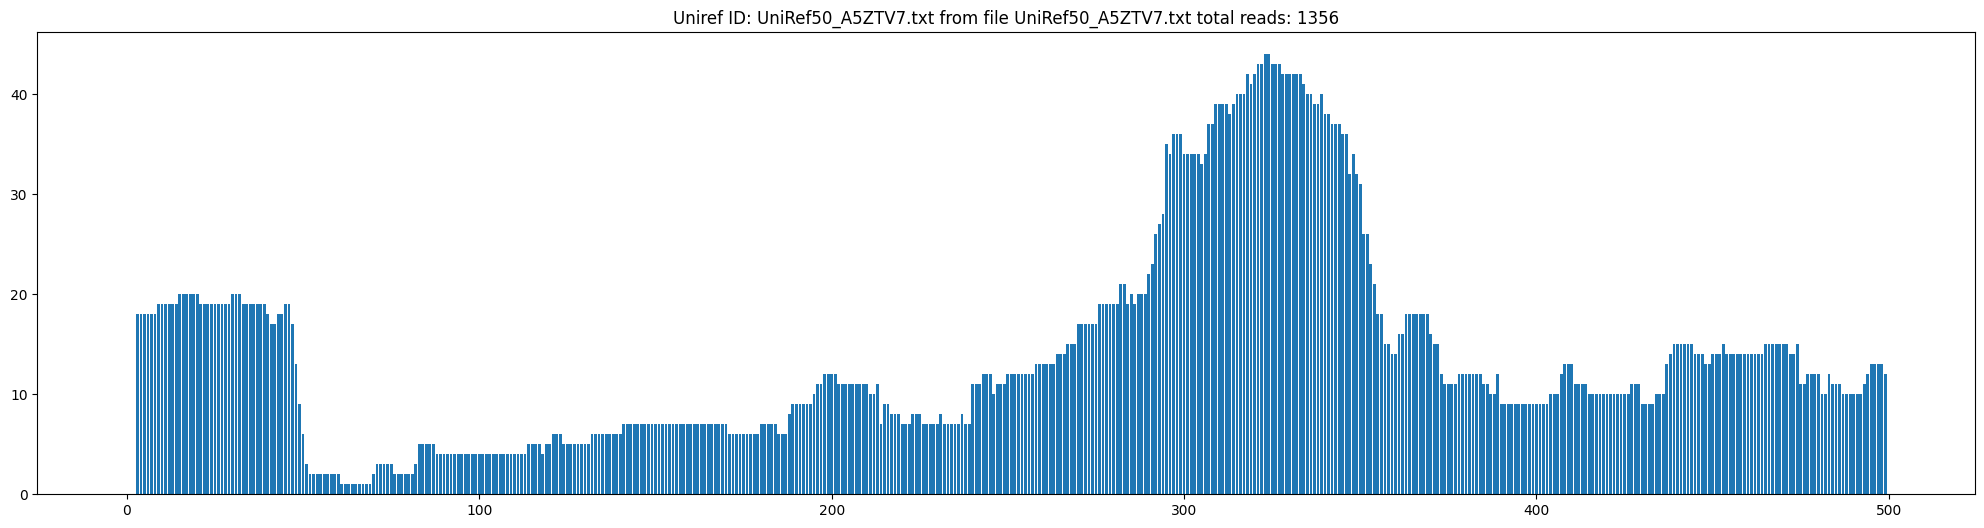

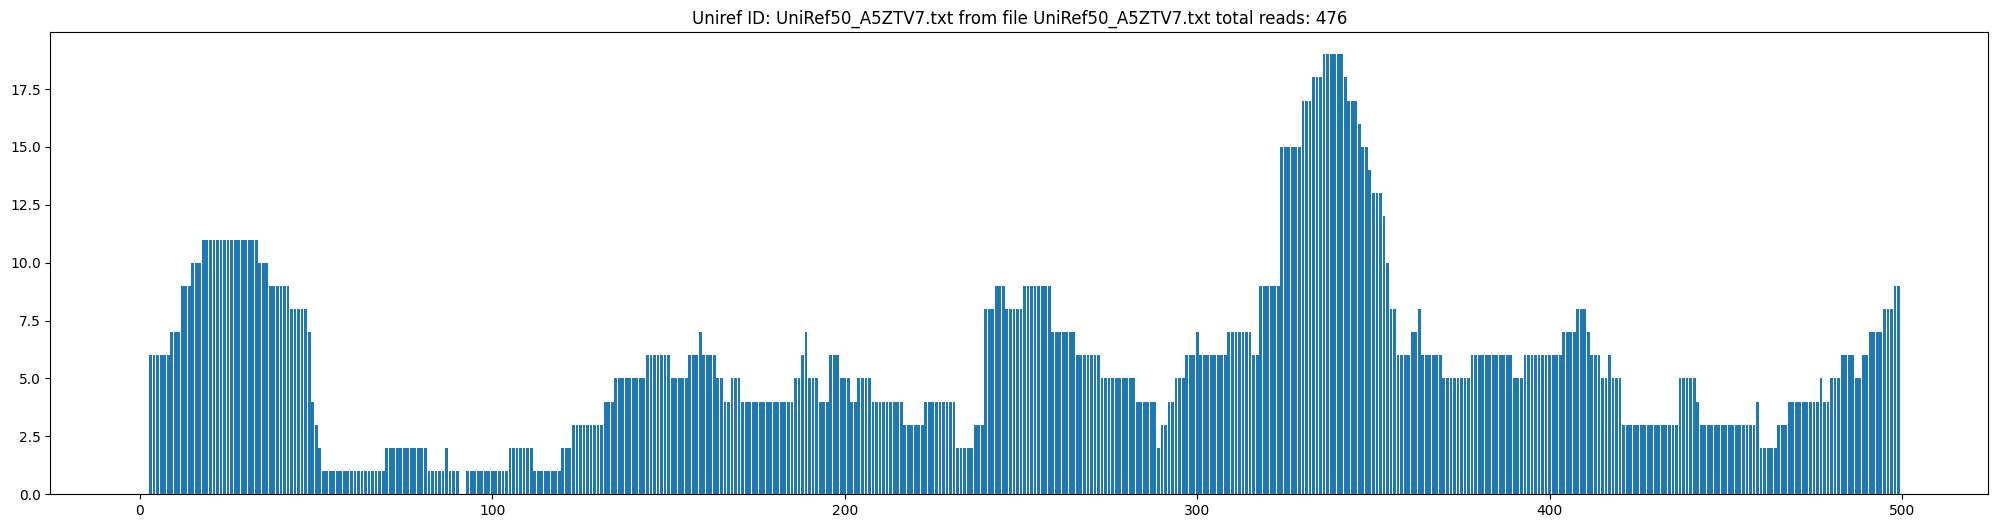

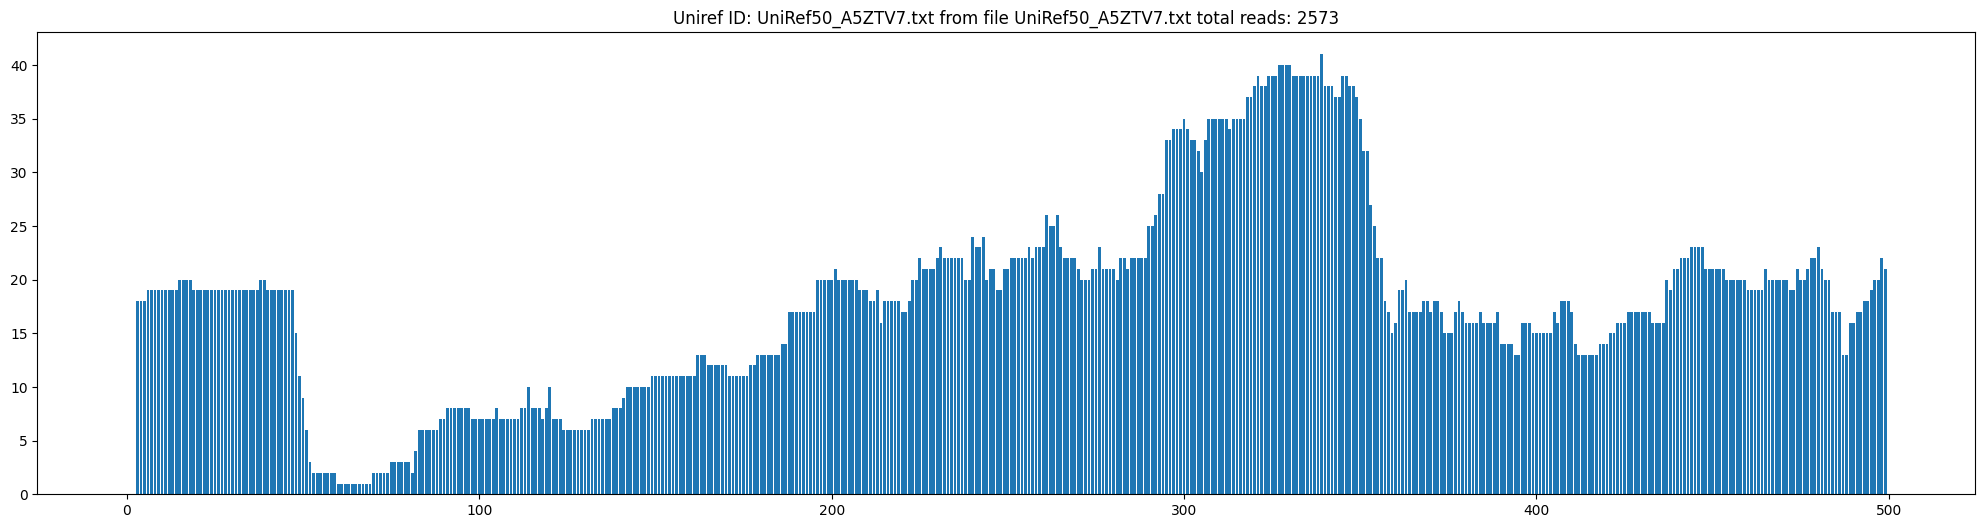

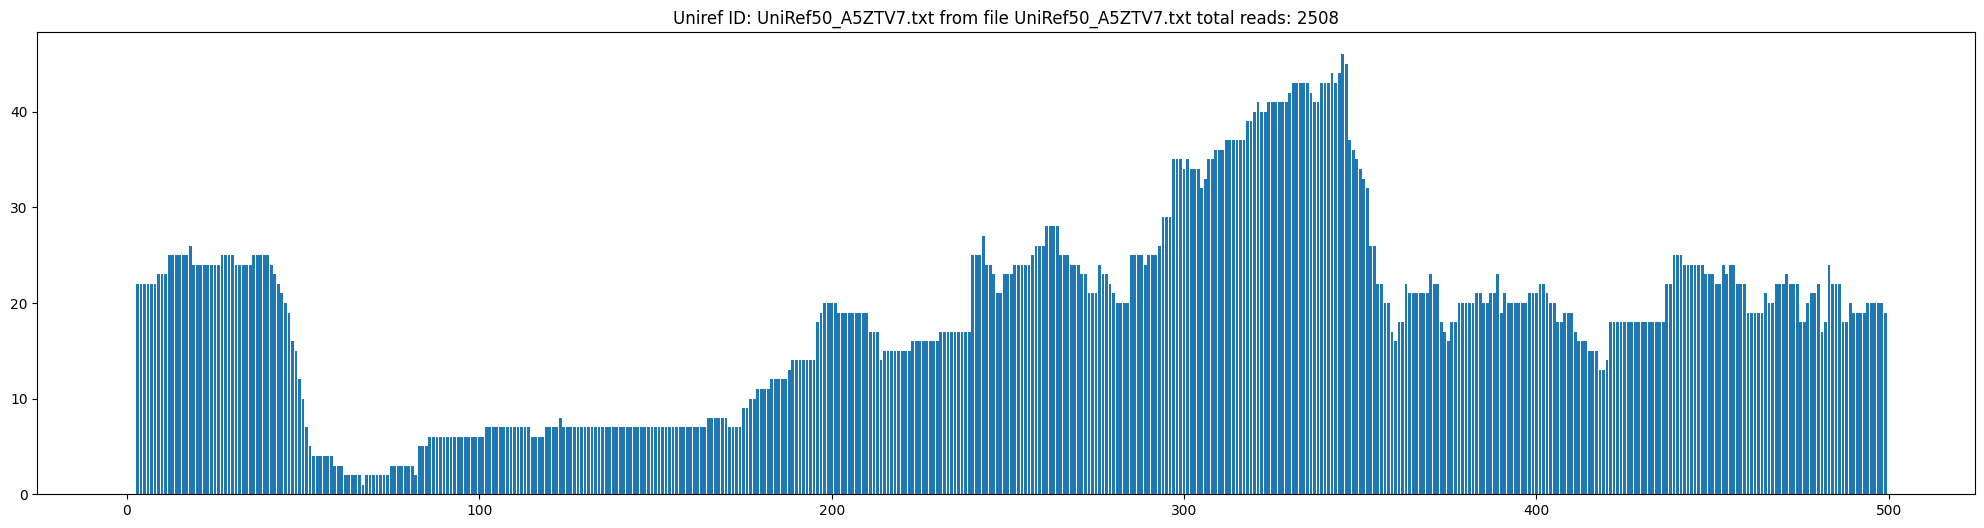

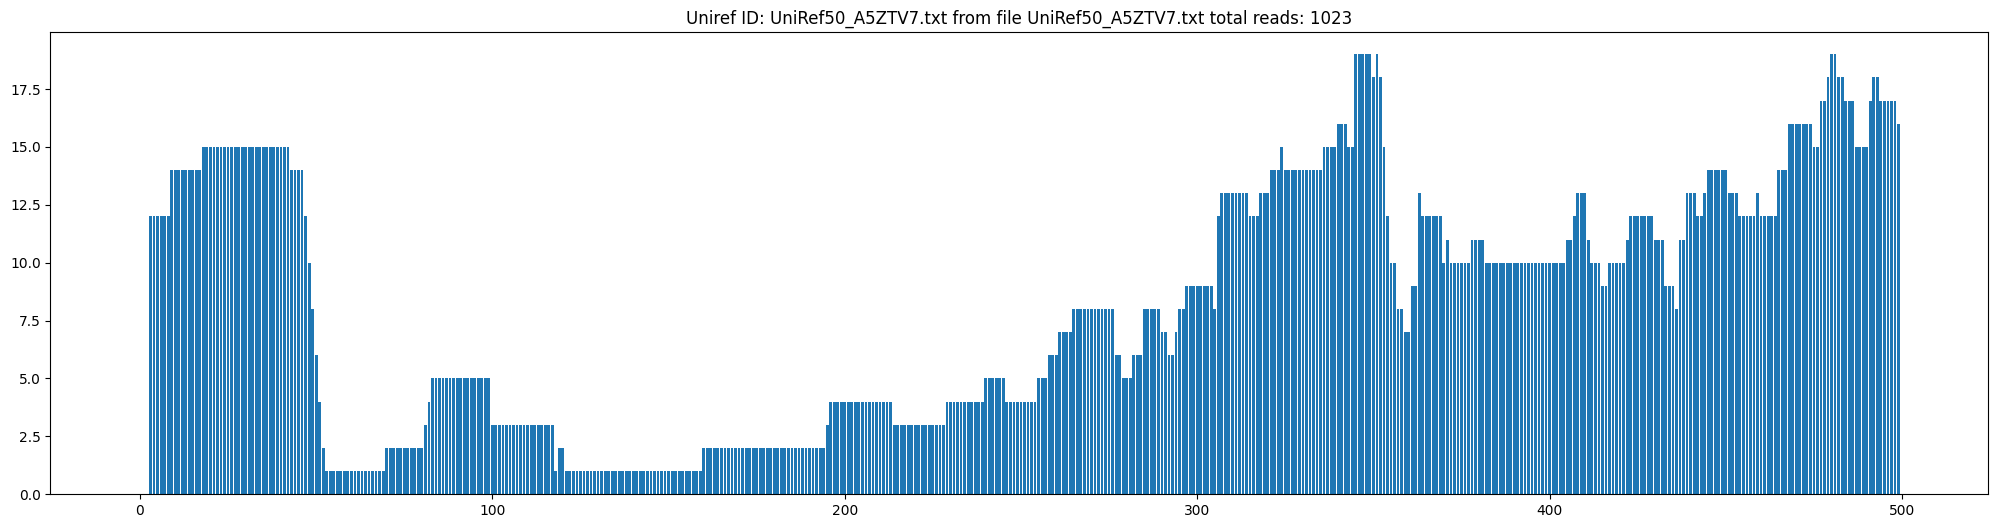

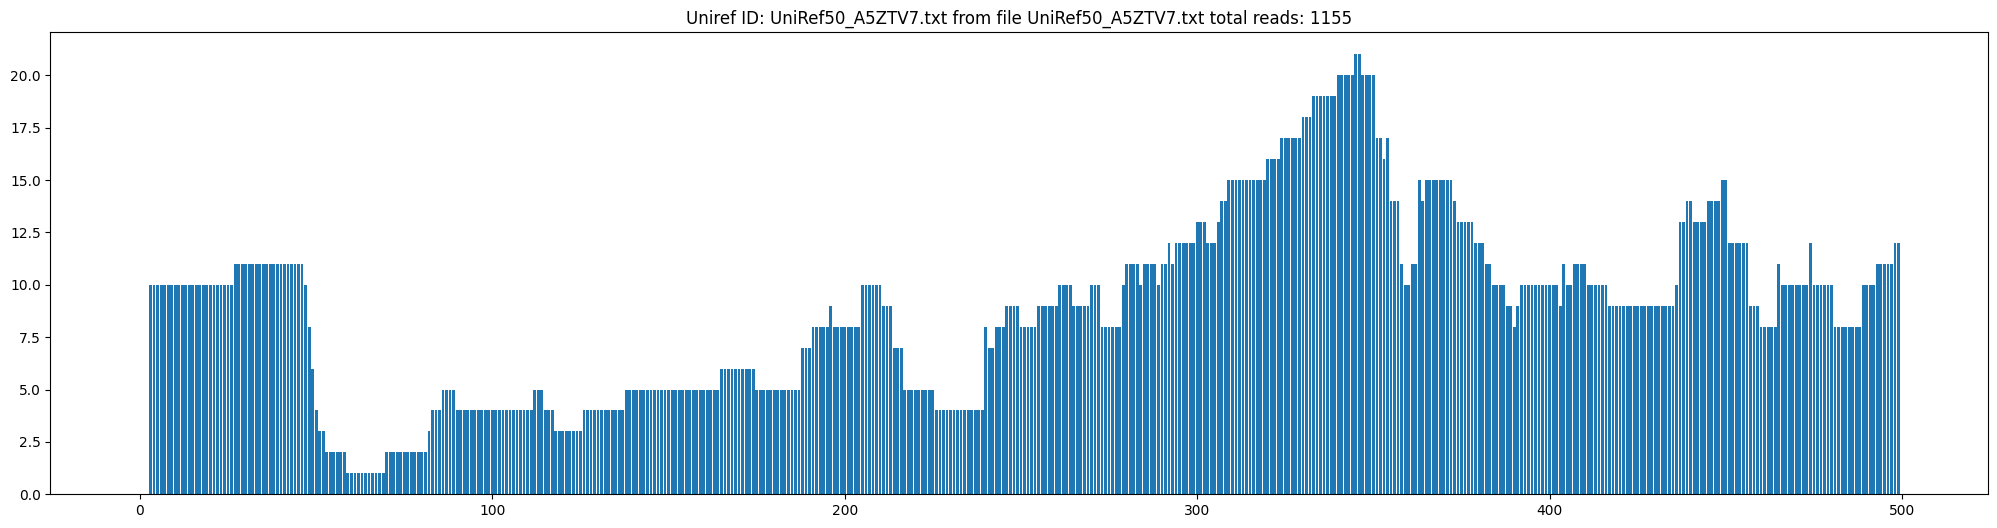

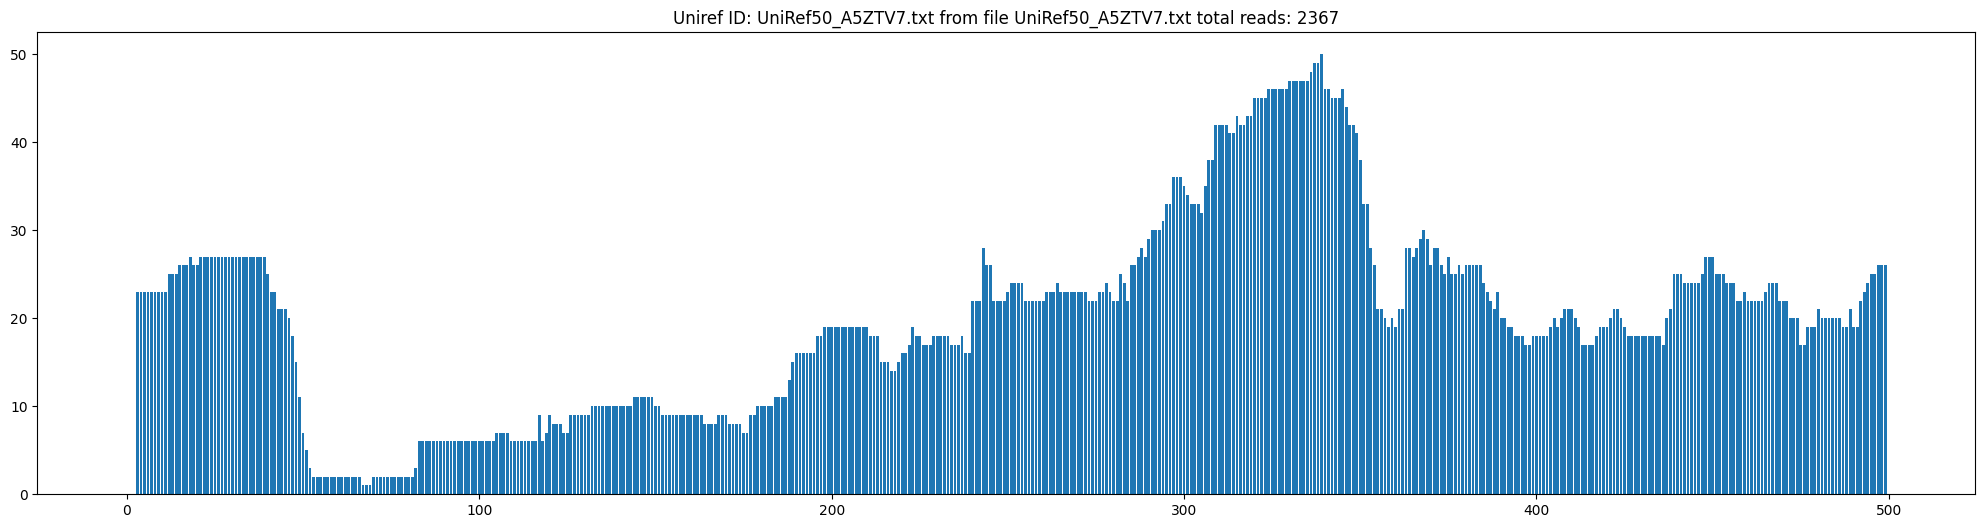

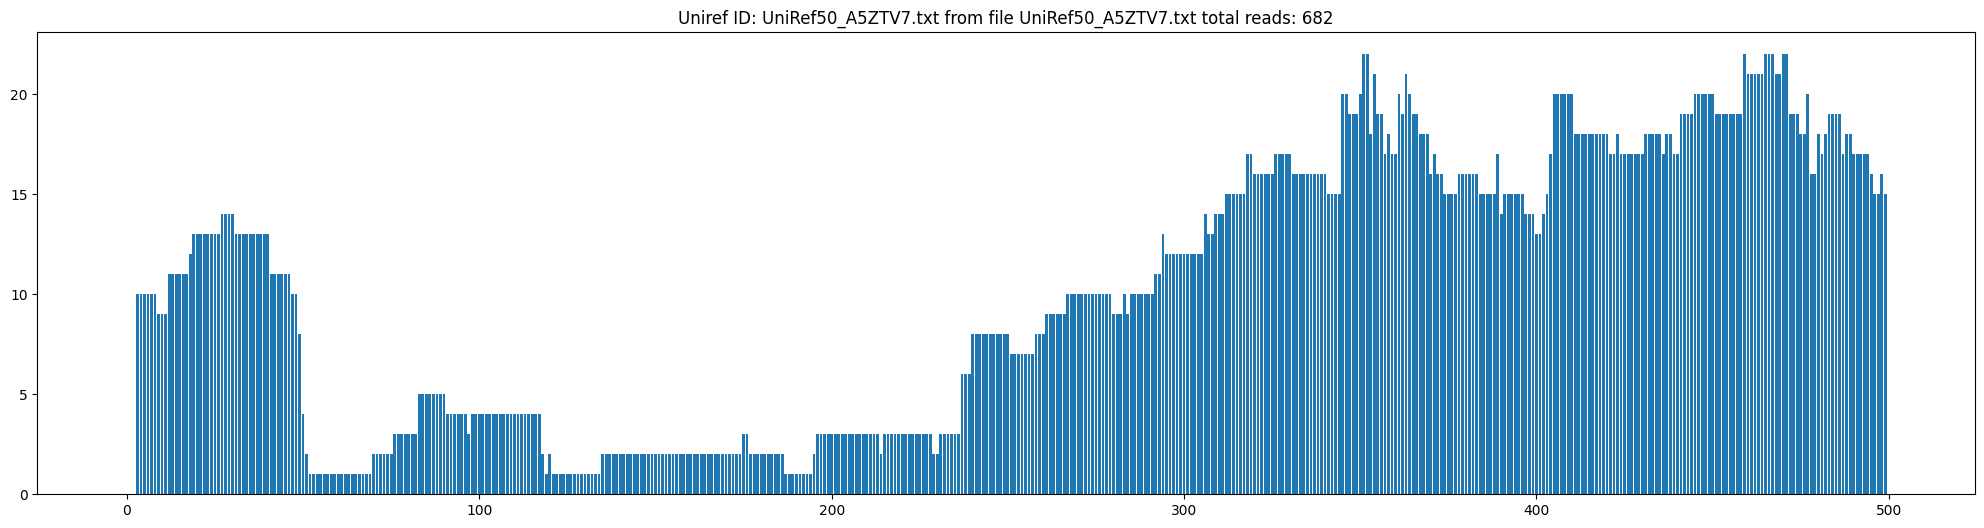

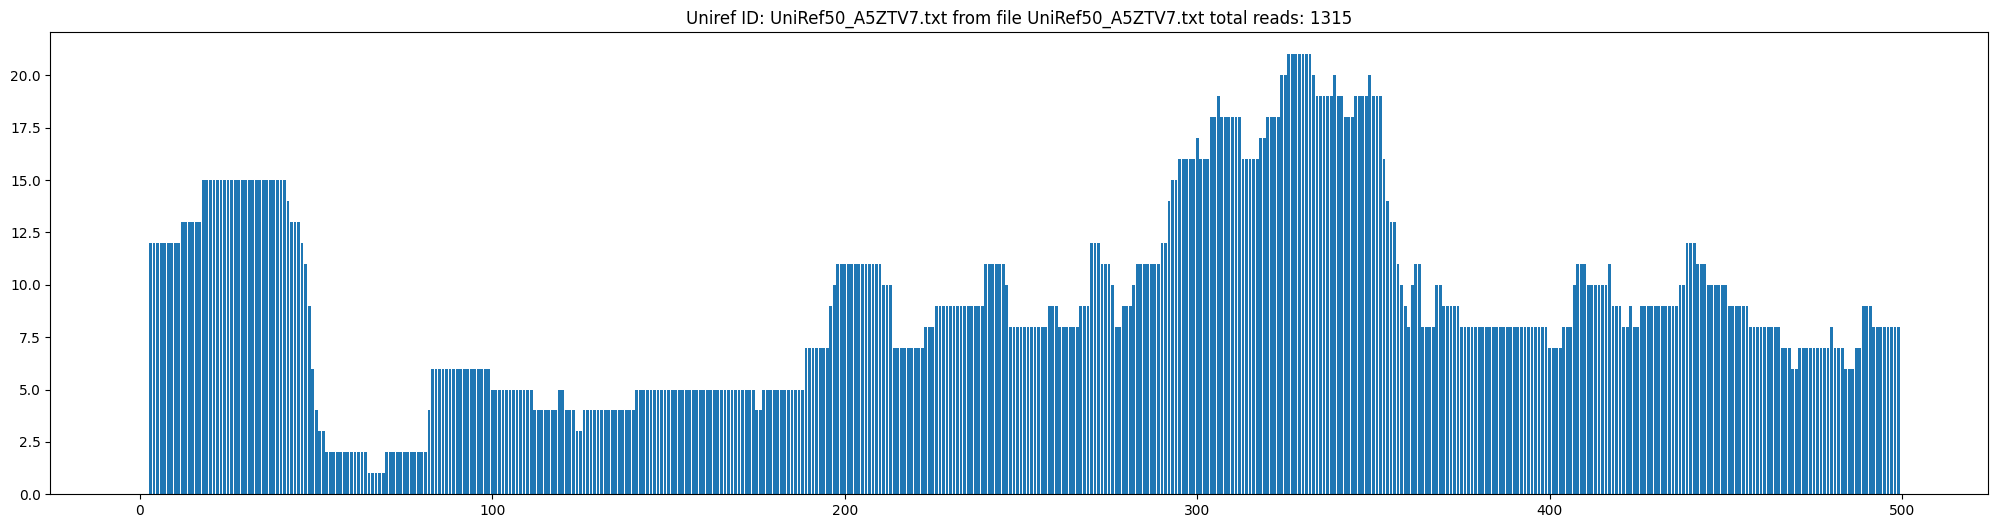

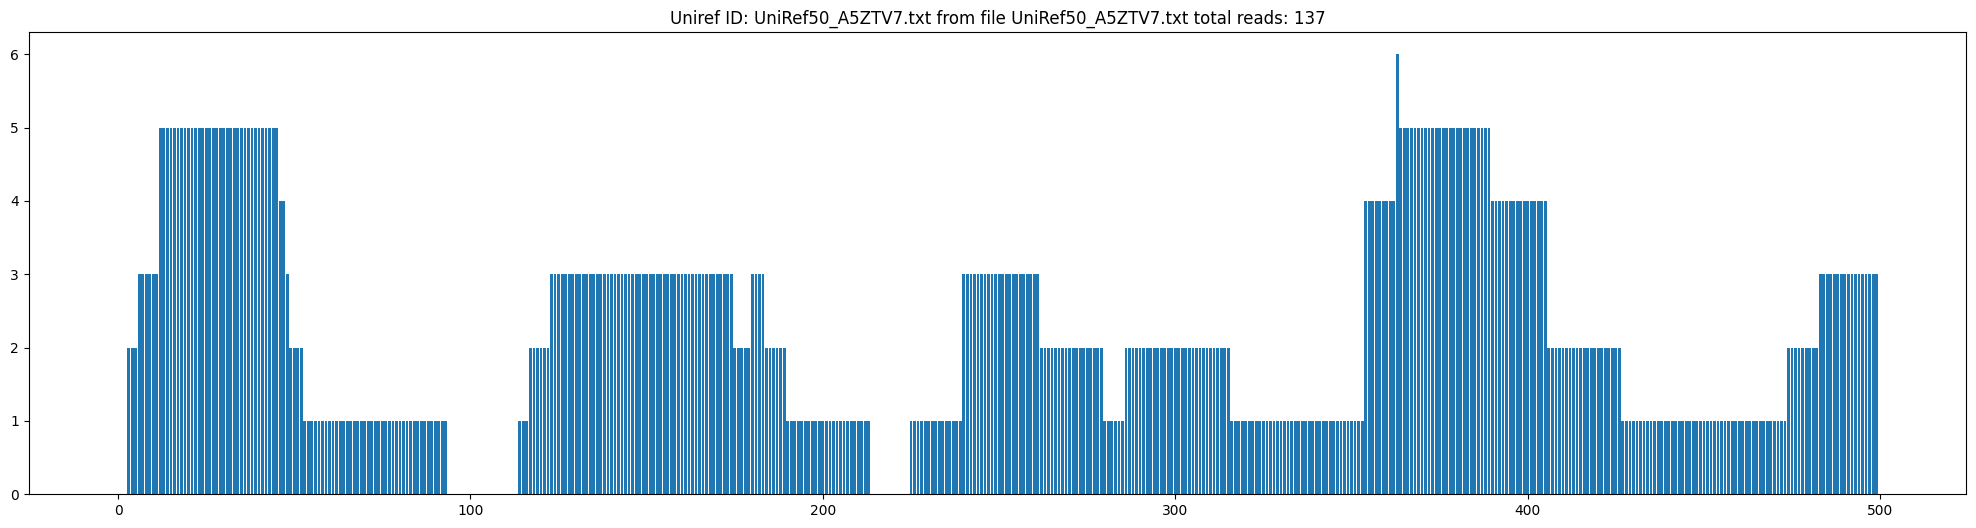

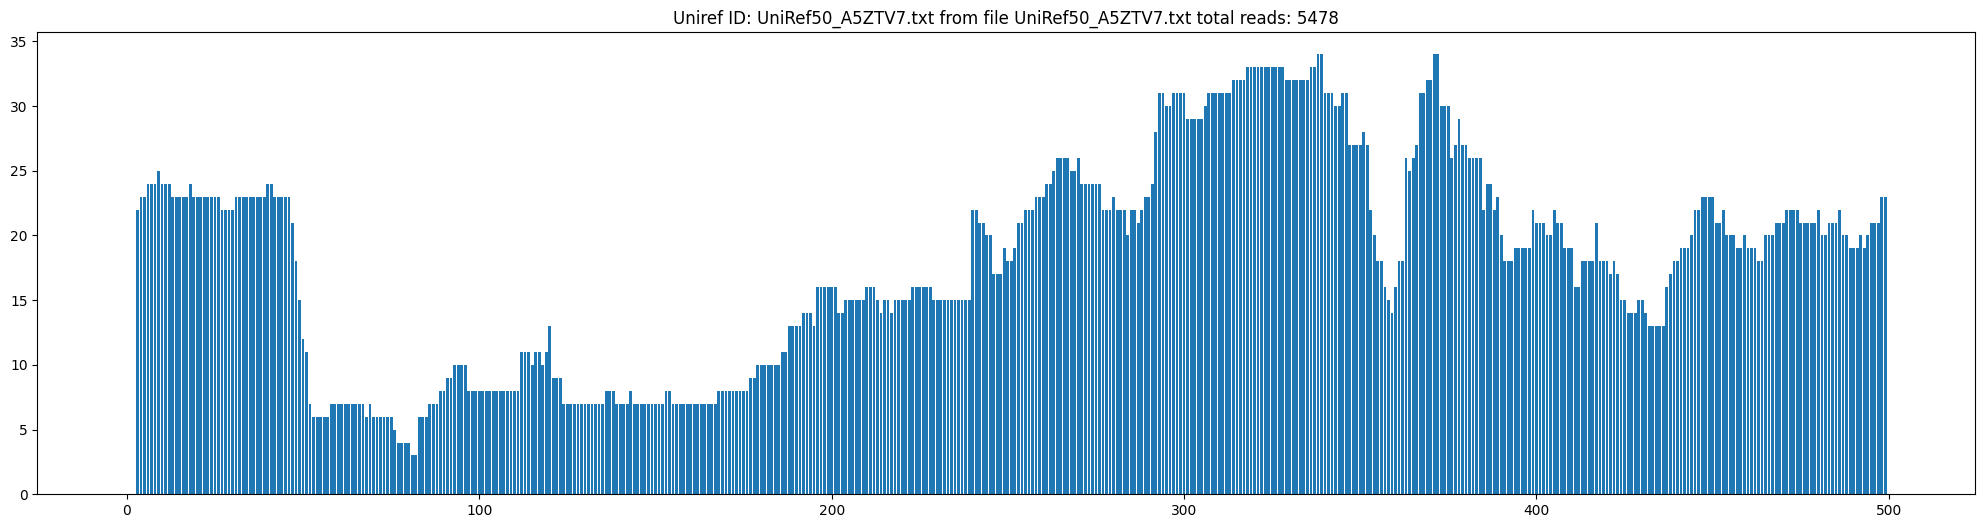

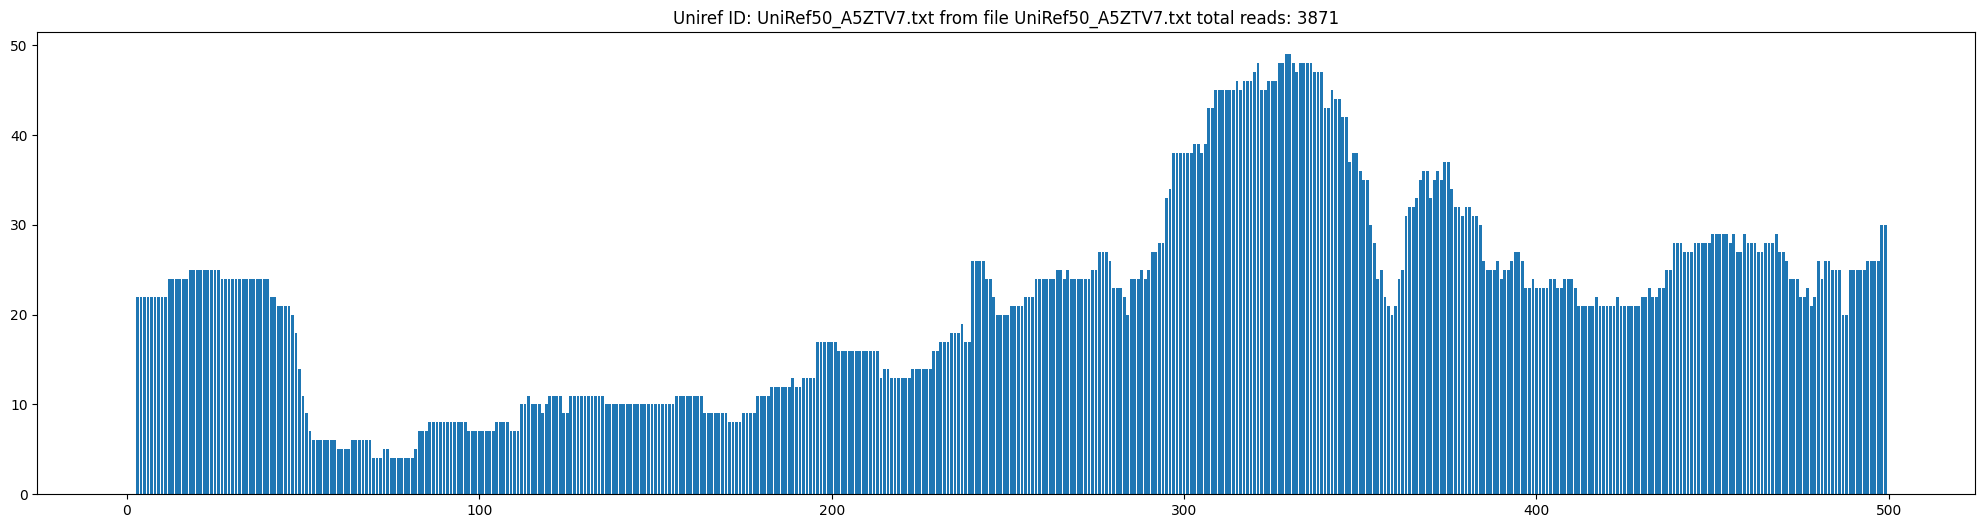

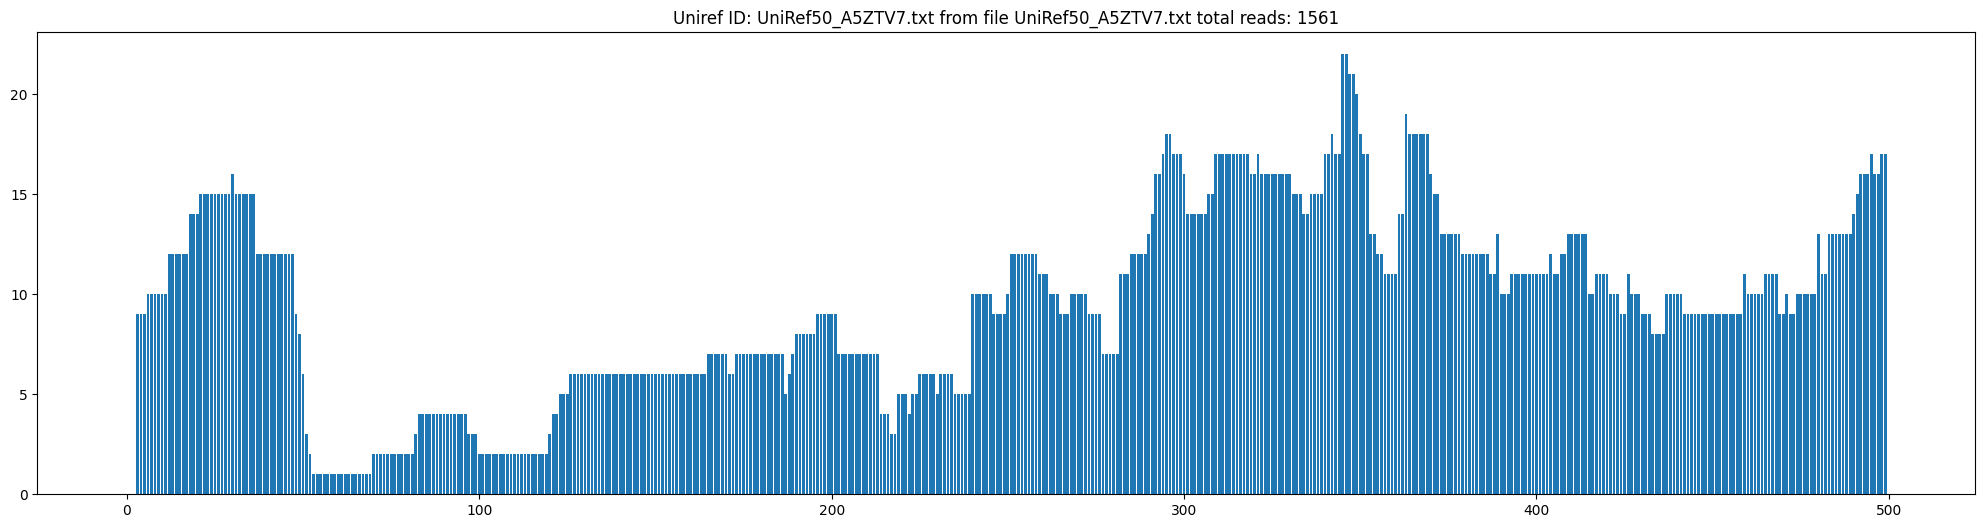

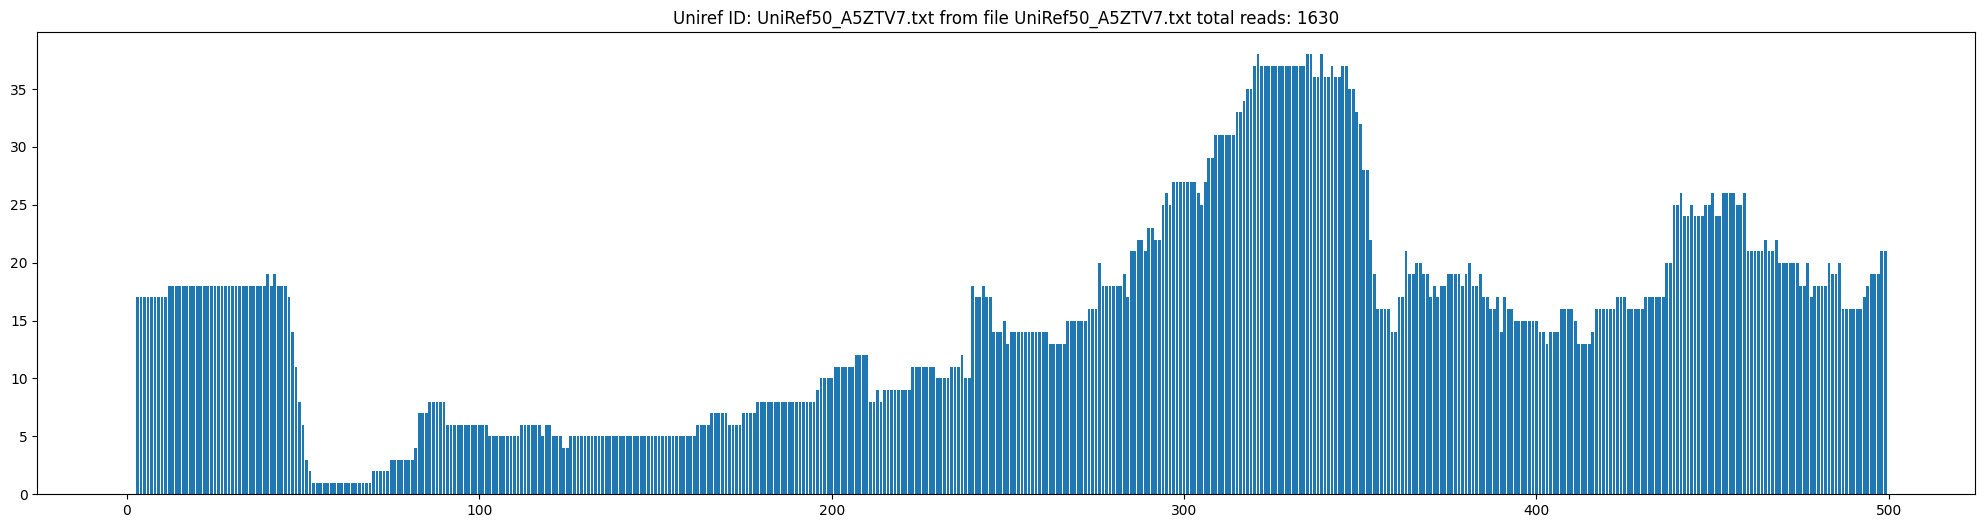

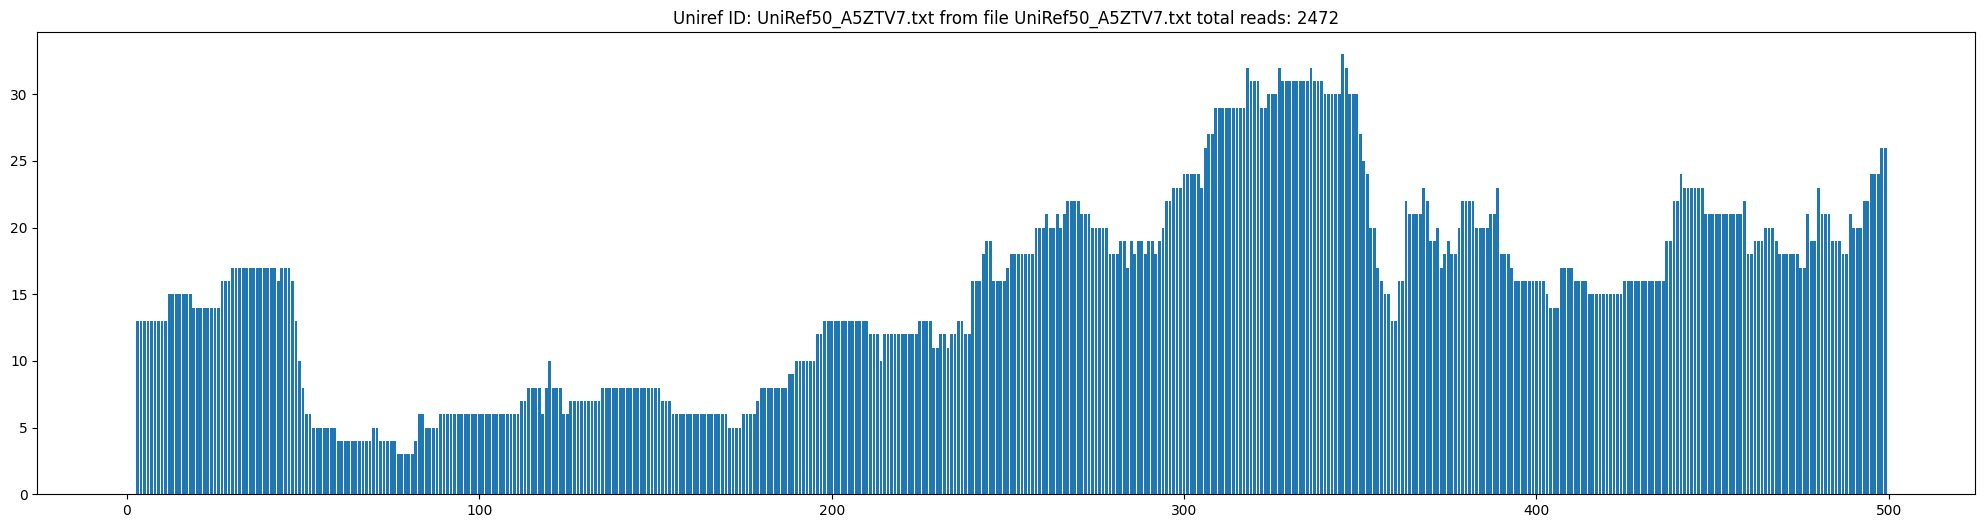

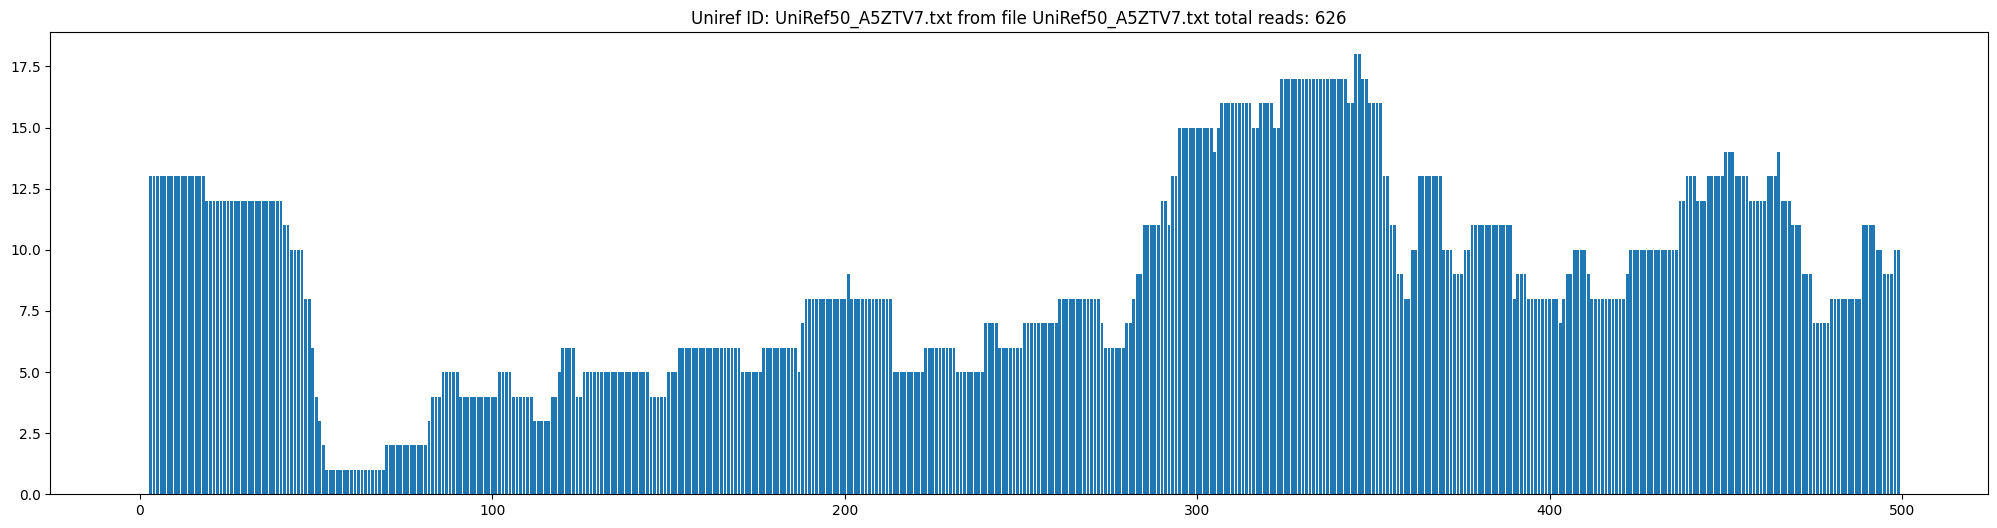

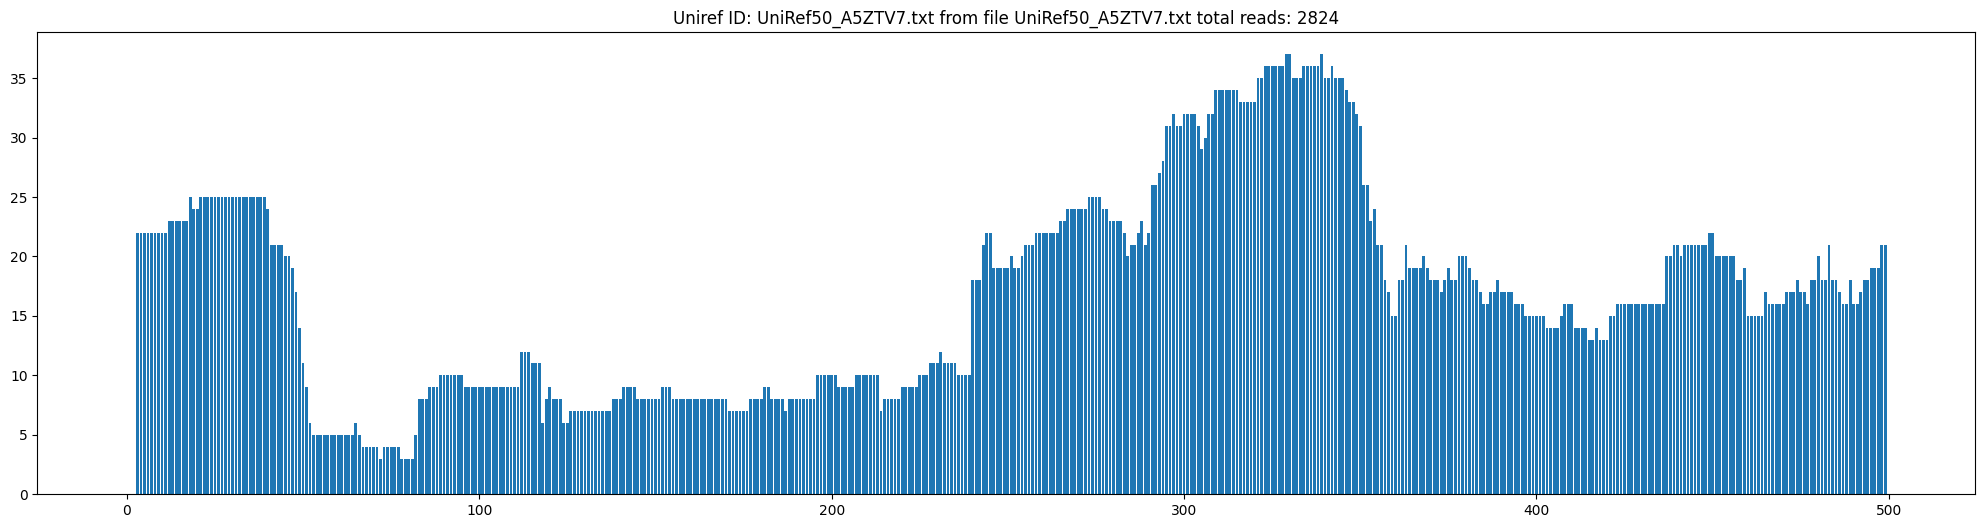

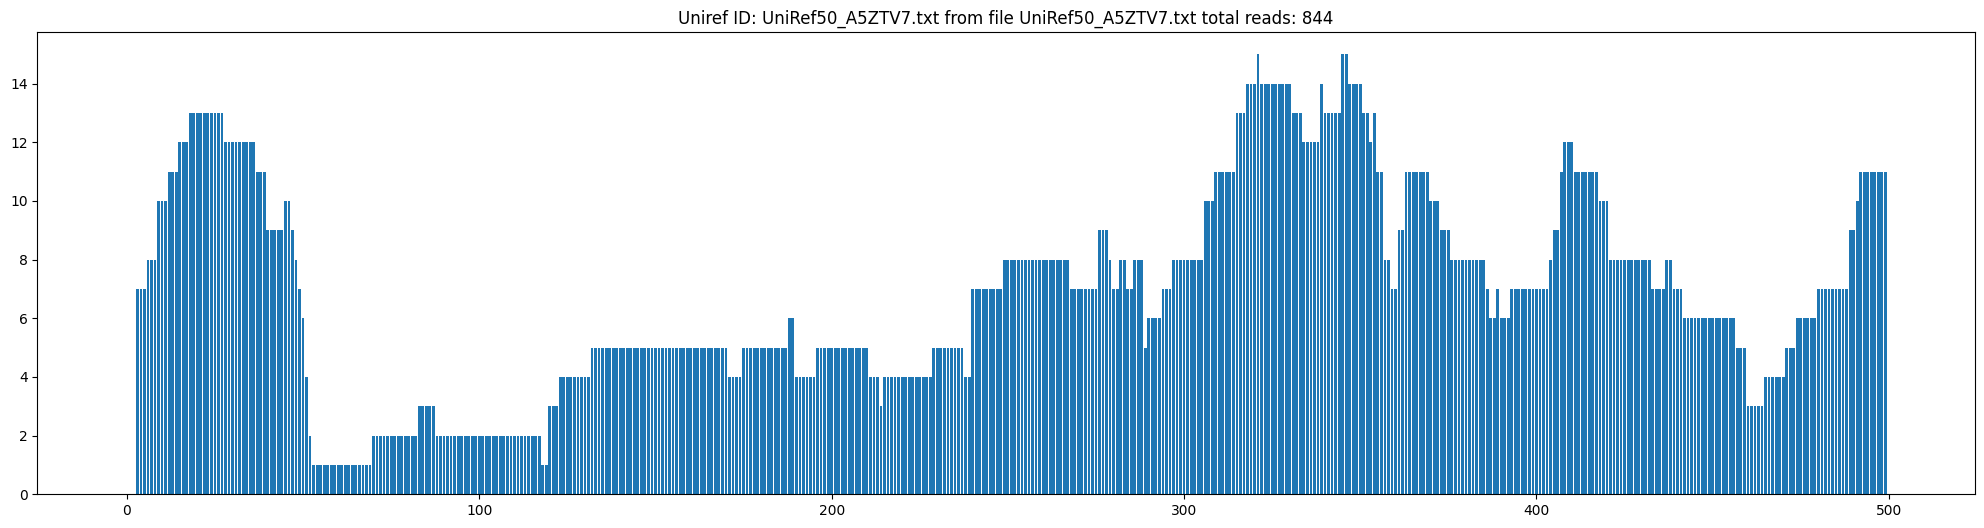

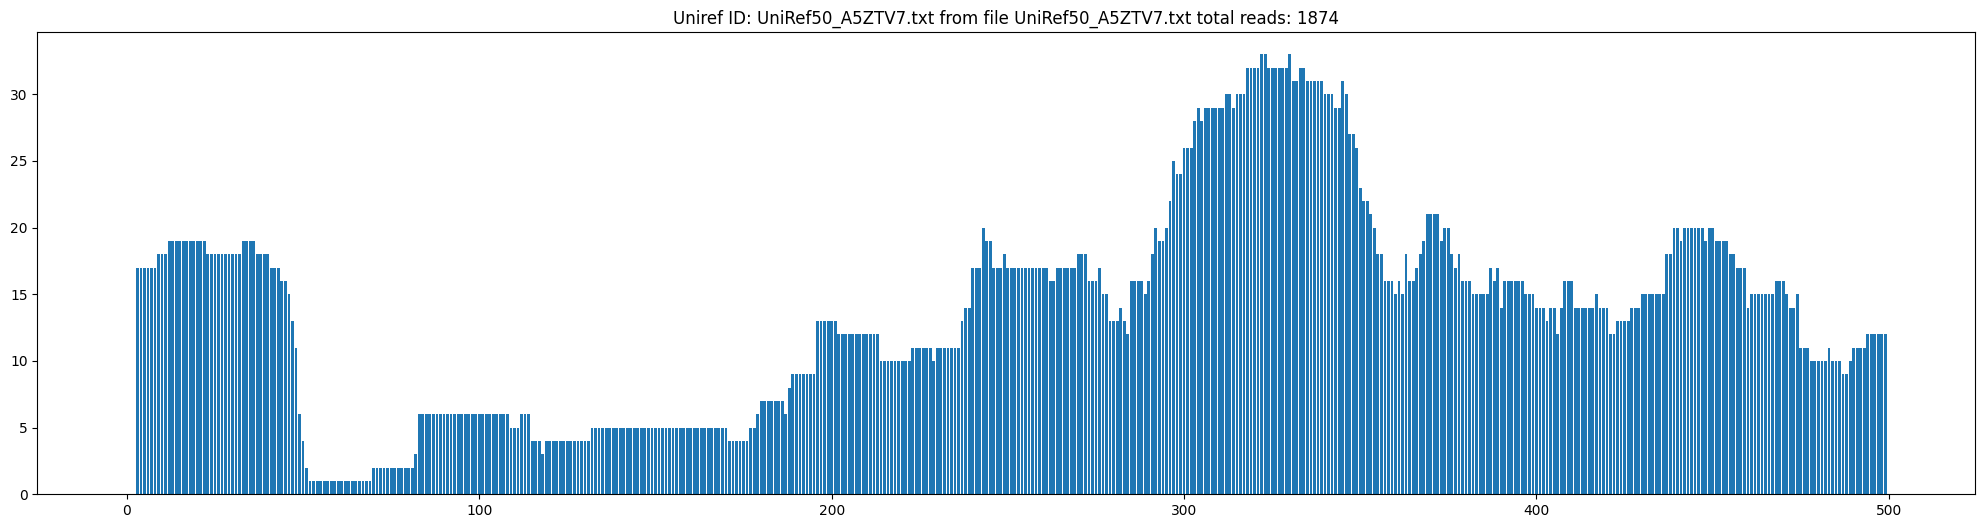

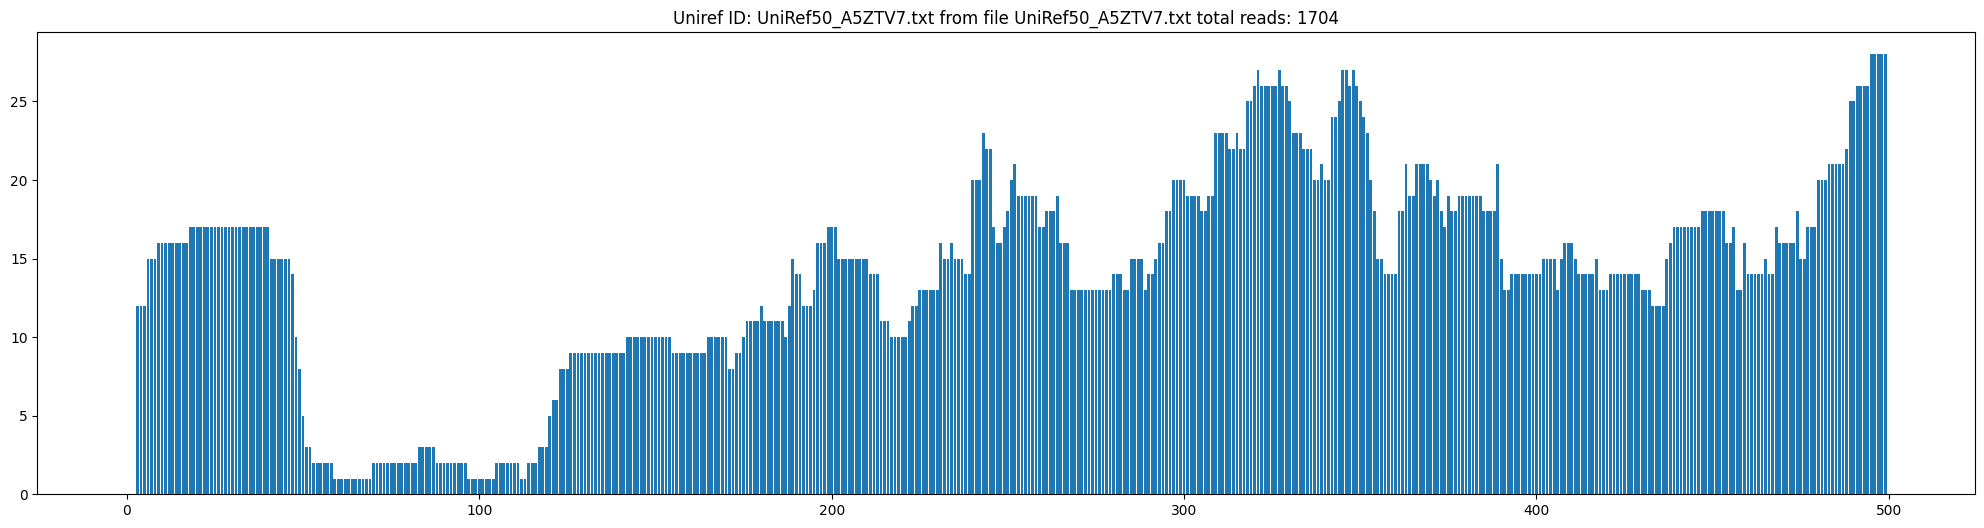

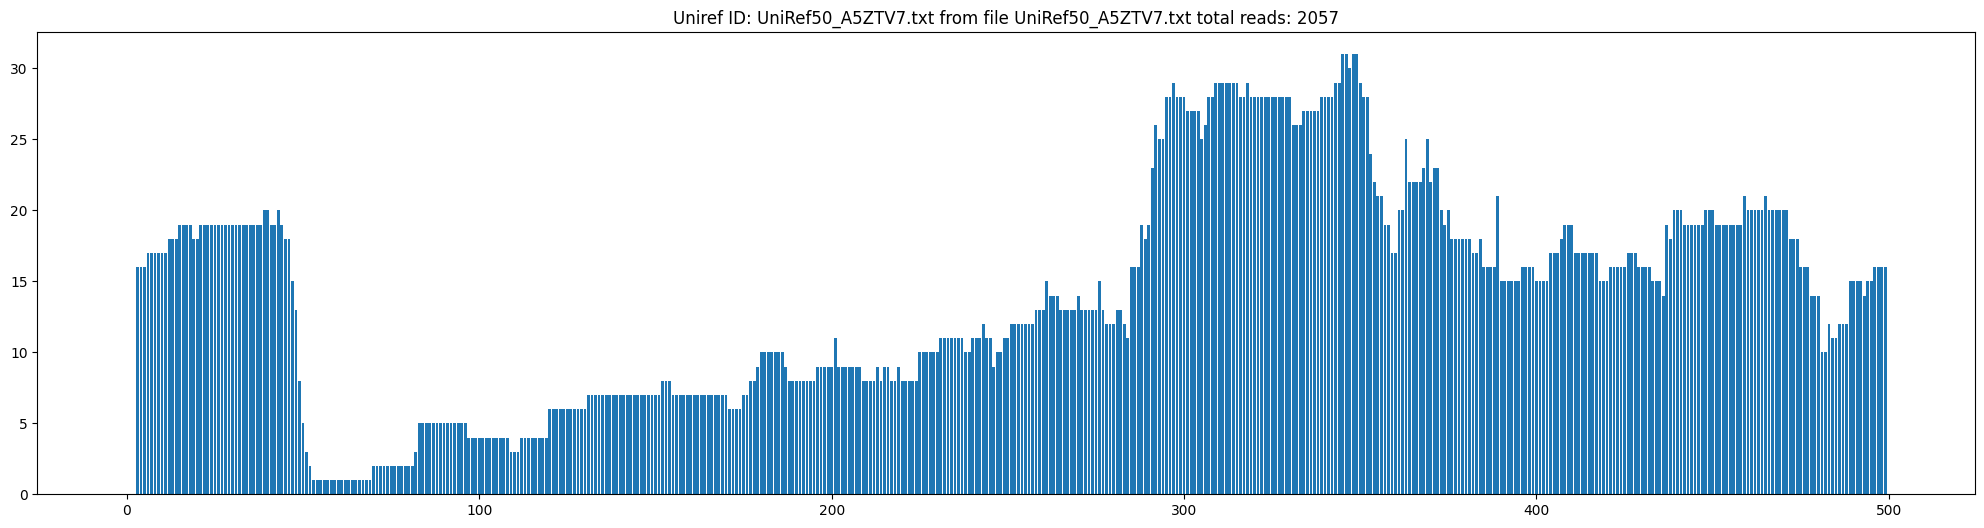

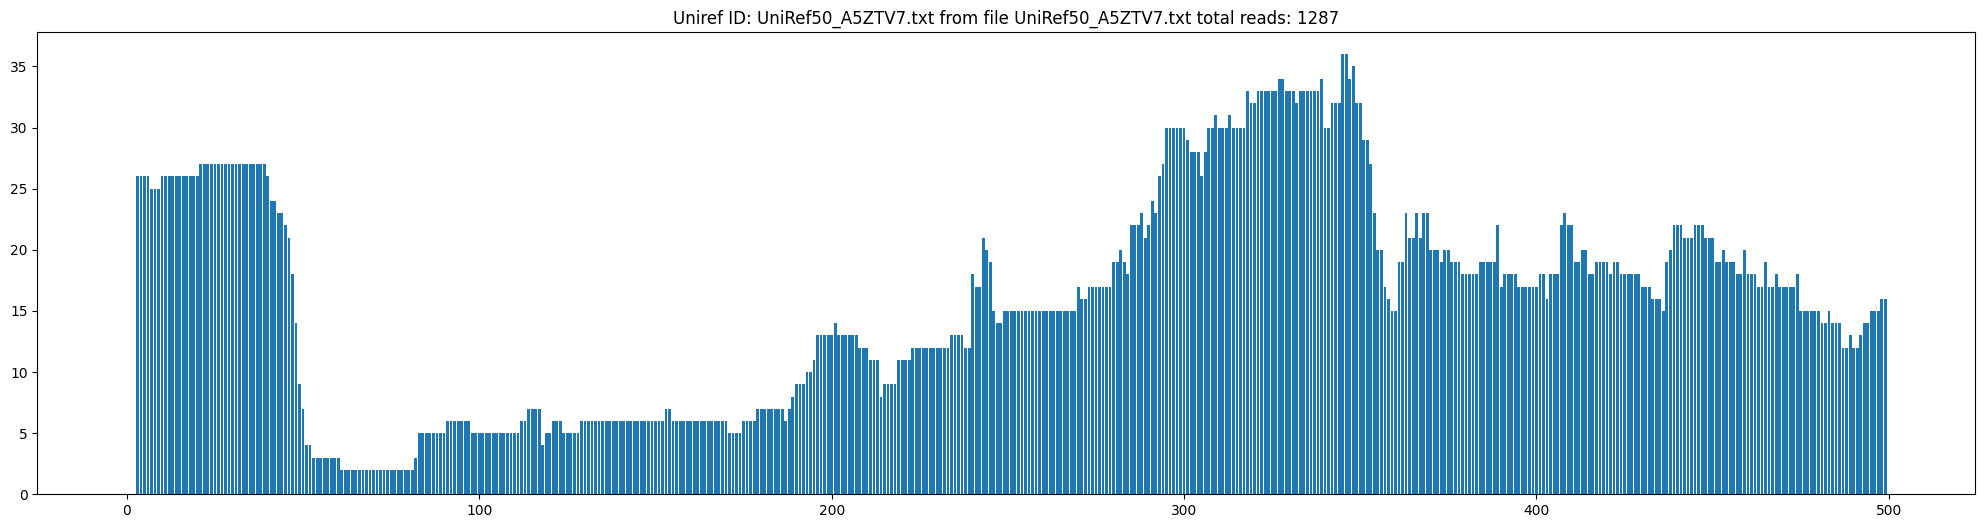

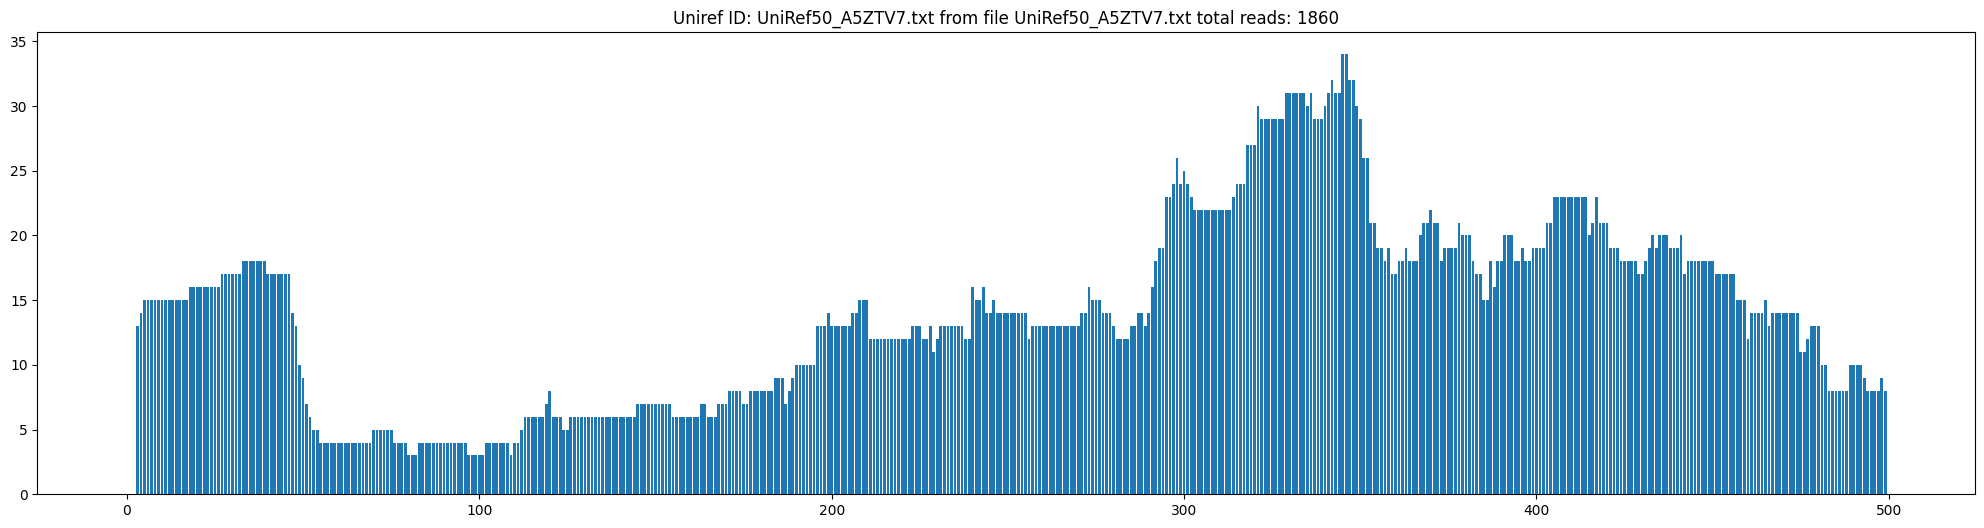

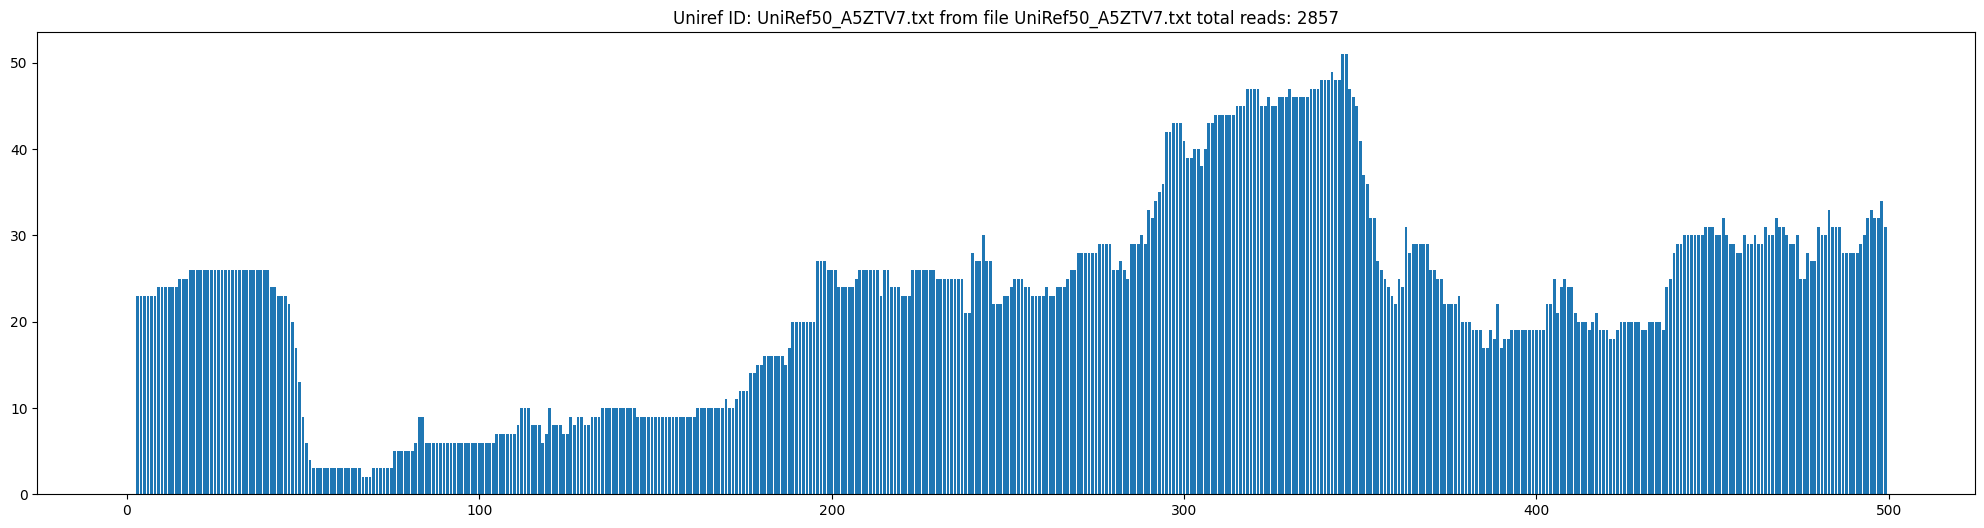

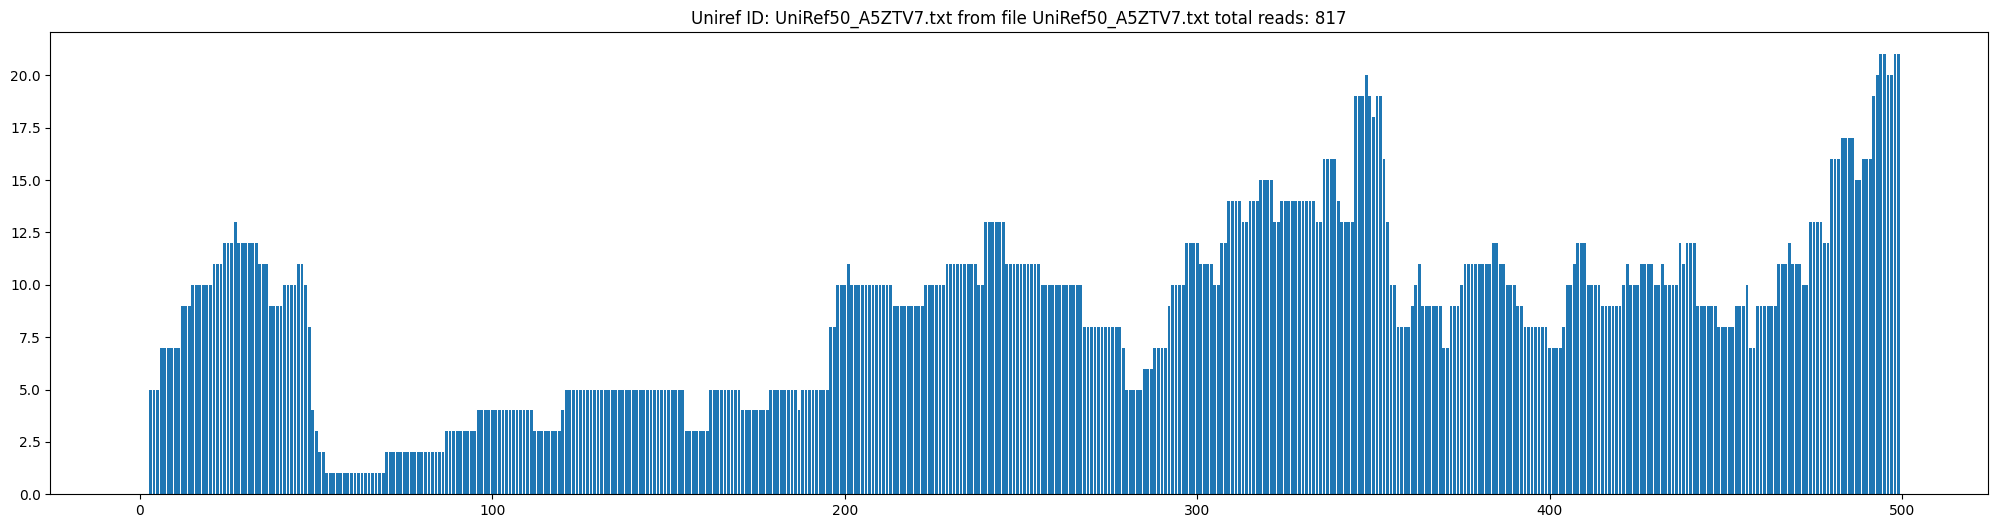

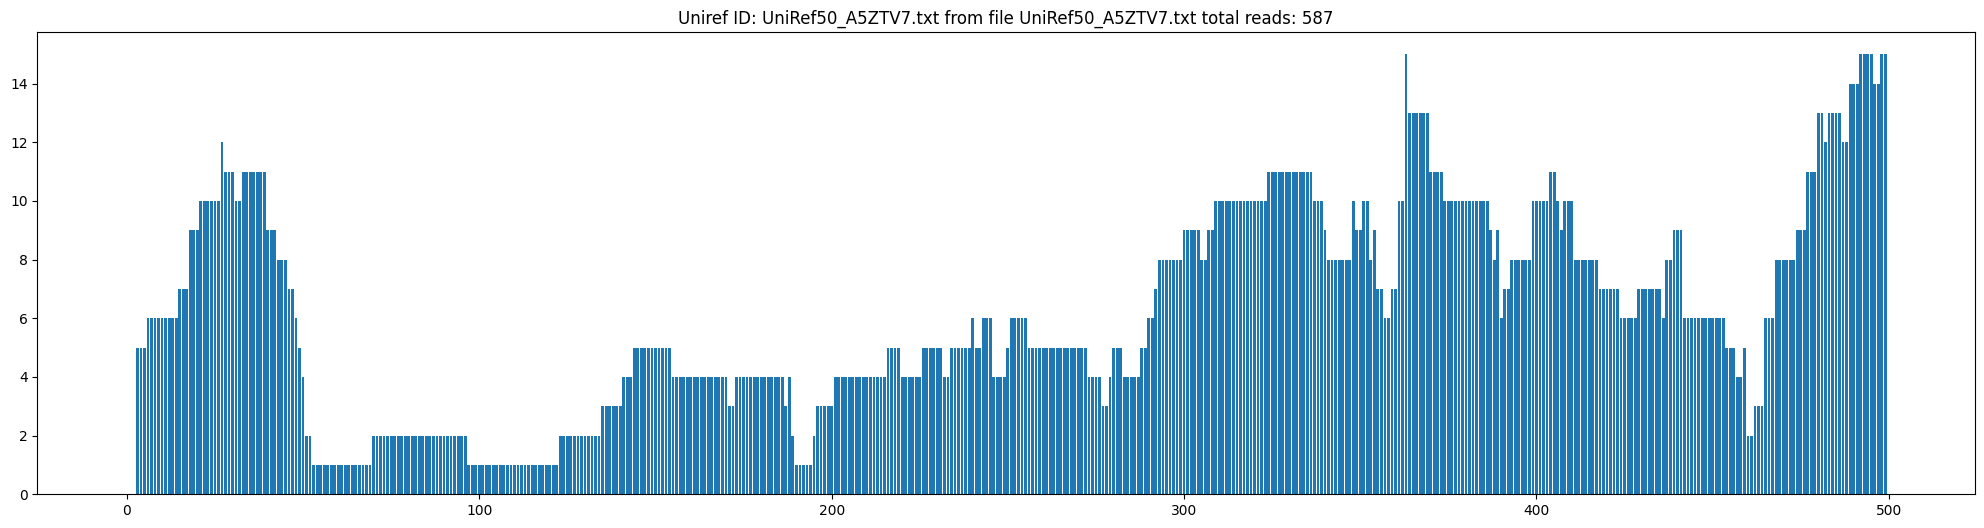

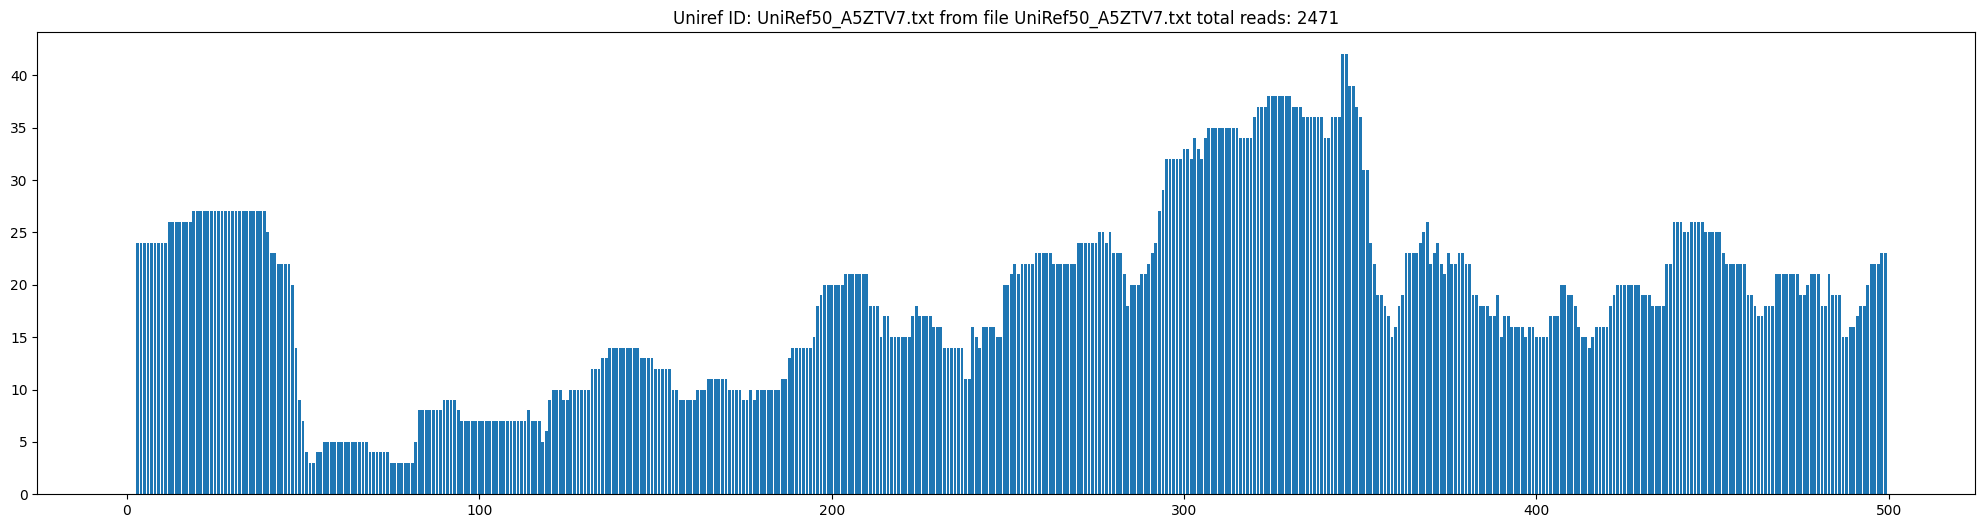

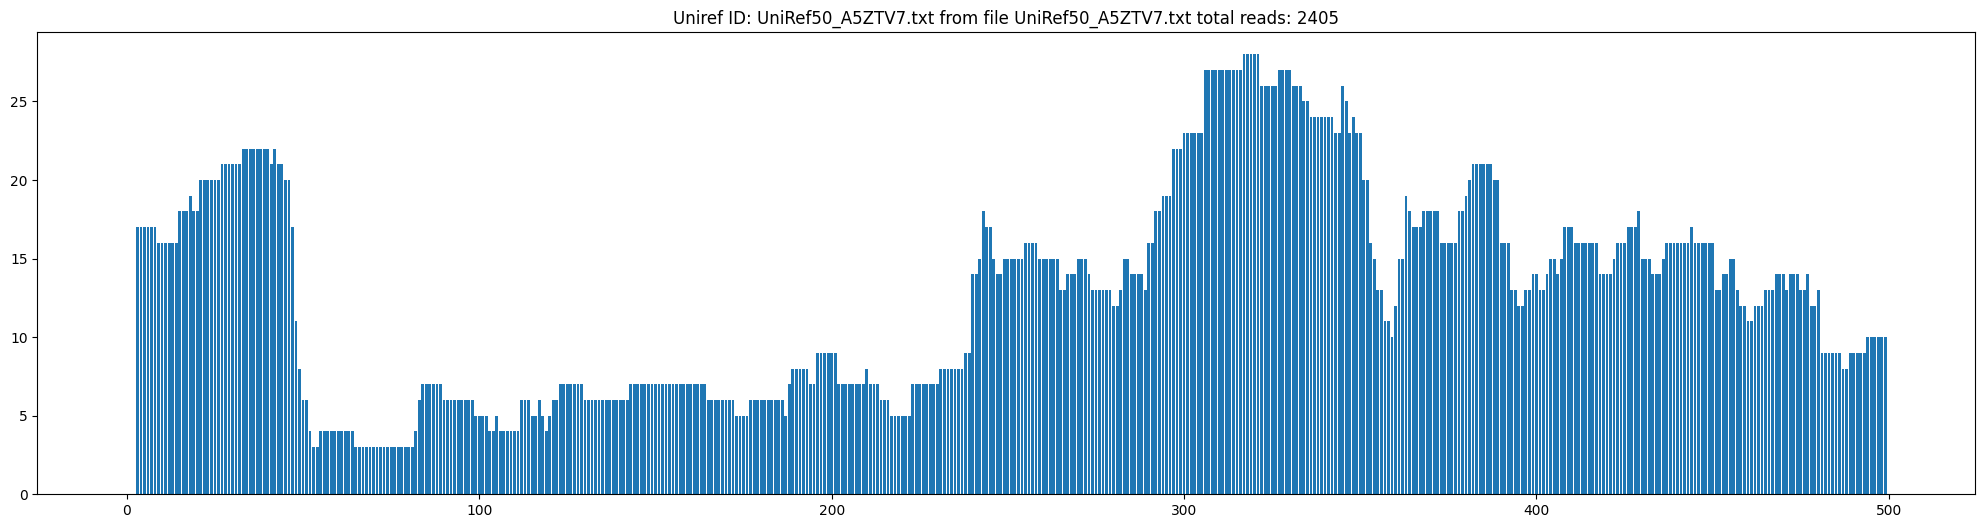

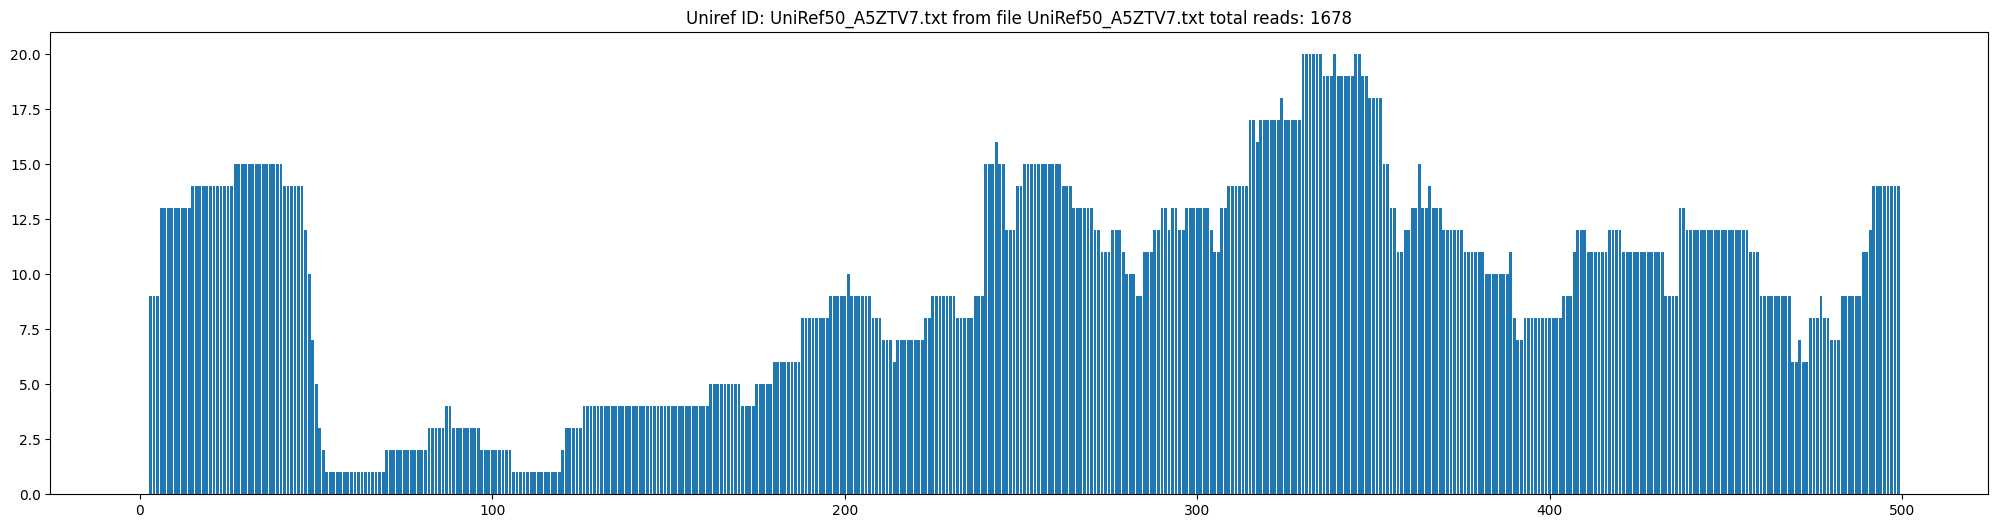

In [108]:
base_dir = '/pita/users/amnon/shotgun/human-cd'
# uniref_id = 'UniRef50_P31206.txt'
uniref_id = 'UniRef50_A0AB34R4B5.txt' # bacteroides plasmid
# uniref_id = 'UniRef50_A0A4Q5C5N8.txt' # bacteroides plasmid
# uniref_id = 'UniRef50_A0A6N3AD02.txt' # bacteroides plasmid
# uniref_id = 'UniRef50_A0A8R1TNR3.txt' # lots of variants
# uniref_id = 'UniRef50_A0A1A9ASF0.txt' # lots of variants
# uniref_id = 'UniRef50_A0A6M2CTG1.txt' # lots of variants
# uniref_id = 'UniRef50_A0A1A9AJP7.txt' # lots of variants
# uniref_id = 'UniRef50_A0A1A9ASW2.txt'
# uniref_id = 'UniRef50_A0A8R1TNC4.txt'
# uniref_id = 'UniRef50_UPI001FB1681A.txt'
# uniref_id = 'UniRef50_UPI001146C460.txt'
# uniref_id = 'UniRef50_A0A8R1TNS2.txt'
# uniref_id = 'UniRef50_G5BD41.txt'

# uniref_id = 'UniRef50_C7H9G6.txt'

# antibiotic resistance
# uniref_id = 'UniRef50_A0A3G2HI72.txt'
# uniref_id = 'UniRef50_A0A150L3D1.txt'
# uniref_id = 'UniRef50_A0A0H3JTK0.txt'
# uniref_id = 'UniRef50_E0Q639.txt'
# uniref_id = 'UniRef50_F2QCT7.txt'

# uniref_id = 'UniRef50_UPI0005422A95.txt' # bifidobacterium longun plasmid

# uniref_id = 'UniRef50_E8JM76.txt'
# uniref_id = 'UniRef50_A0A3D8HIM8.txt'
# uniref_id = 'UniRef50_Q8A528.txt'

uniref_id = 'UniRef50_A5ZTV7.txt'
all_num, all_tot_reads = parse_results(base_dir, uniref_id, window_size=50, plot_it=True)

In [74]:
all_num

{}

In [31]:
reads = pd.read_csv('/pita/users/amnon/shotgun/human-cd/reads.txt',sep=':', header=None, names=['sampleid', 'reads'])

Text(0.5, 0, 'Number of reads (millions)')

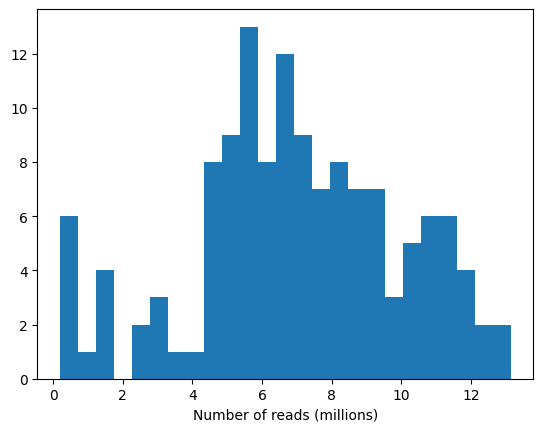

In [36]:
plt.figure()
_=plt.hist(reads['reads']/1E6, bins=25)
plt.xlabel('Number of reads (millions)')